# Individual Project 3

### Table of Content
<ol>
<li>Introduction</li>
<li>Data Sources</li>
<li>Data Preparation</li>
<li>Data Analysis
    <br>- Total Launched Campaign
    <br>- Total Amount of Dollars Raised
    <br>- Campaign Success Rate
    <br>- Campaign Duration
    <br>- Campagin Fundings 
    <br>- Campaign Categories
    <br>- Campaign Title and Tagline
<li>Data Cleaning and Processes</li>
<li>Conclusion and Prediction</li> 
<li>References</li>
</ol>

Introduction

“Crowdfunding refers to the efforts by entrepreneurial individuals and groups—cultural, social, andfor-profit—to fund their ventures by drawing on relatively small contributions from a relatively largenumber of individuals using the internet, without standard financial intermediaries (Mollick, 2013, p.2).”

Crowdfunding first appeared in the UK back in 2007 (2019). The concept of pledging public support for an idea or a prototype through an online presentation on a website soon gained popularity in various countries across continents. As crowdfunding has gained attention, it has become a widespread practice for startups to seek funding from the general public in recent years.

In 2013, a study conducted by a former crowdfunder indicated that more than 90% of startups sought funding on crowdfunding websites (Drake, 2017). Among all those websites, Kickstarter and Indiegogo are the two most prominent platforms within the community (Barnett, 2015). Both were founded in the US. Indiegogo was founded in 2008; it hosted more than 800,000 campaigns. Kickstarter was launched in April 2009. It has accumulated 174,751 successfully funded projects and raised more than $4 billion. In 2019, the QY Research report showed that the size of the global crowdfunding market will probably continue increasing thousands for the next five years (2019).

Previous studies have primarily focused on the dynamic among backers and crowdfounders. However, it is crucial to study which elements a project needs to meet to increase the odds of success.

To determine the qualities of a successful project, this study examines project data from two platforms across four shared perspectives: total number of campaigns, total funds raised, success rate, campaign duration, and campaign categories. Also, it aims to analyze the top words used in project titles and taglines.

# Data Source
    
Kickstarter Dataset: Web Robots 
Link: https://webrobots.io/kickstarter-datasets/

Indiegogo Dataset: Web Robots 
Link: https://webrobots.io/indiegogo-dataset/

# Data Cleaning

In [2]:
# Import html modudel for
from IPython.core.display import display, HTML
from IPython.display import Image

# Import pandas module and set the display setting to allow all the columns appeared 
import pandas as pd
pd.set_option('display.max_rows', 500)
pd.set_option('display.max_columns', 500)
pd.set_option('display.width', 1000)

# Import datetime module
from datetime import datetime

# Import zip and os module
import zipfile
from zipfile import ZipFile 
import os 
from os import listdir
from os import path

# Import matplotlib and plotly module
import matplotlib.pyplot as plt
from matplotlib import rcParams
import plotly.express as px
import plotly.graph_objects as go

# Import numpy and worldcloud module
import numpy as np
from PIL import Image
from wordcloud import WordCloud, STOPWORDS, ImageColorGenerator

# Import NLP module
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize, sent_tokenize
stop_words = set(stopwords.words("english")) #getting the stop words that are built-in


### <center> Data Cleaning Kickstarter
### <center> Import Files

In [3]:
# Read in all the files from the zip folders
# Change the directory 
os.chdir('/Users')
filepaths = [f for f in listdir("/Users") if f.endswith('.csv')]
df = pd.concat(map(pd.read_csv, filepaths))

# Change the file as dataframe
raw = pd.DataFrame(data=df)

# Check the shape of the raw dataframe
display(HTML('<h3><center>----------Kicistarter Raw Shape----------</center></h3>'))
display(raw.shape)

# Check the raw table head and tail 
display(HTML('<h3><center>----------Head----------</center></h3>'))
display(raw.head(3))

# Seperate two diplay for better 
display(HTML('<h3><center>----------Tail----------</center></h3>'))
display(raw.tail(3))

(211424, 38)

In [6]:
# Set id columns as the index of the data frame
raw.set_index('id')

# Use id as a unique id column to filter duplicates 
raw.id.nunique(dropna = True) 

# Drop duplicate rows
raw.drop_duplicates(subset ='id', keep = False, inplace = True) 

# Check the new dataframe shape
display(HTML('<h3><center>----------Kickstarter Shape----------</center></h3>'))
raw.shape

(157646, 38)

In [7]:
# Count the amount of NA numbers inside the dataframe
raw.isnull().sum()

backers_count                    0
blurb                            8
category                         0
converted_pledged_amount         0
country                          0
country_displayable_name         0
created_at                       0
creator                          0
currency                         0
currency_symbol                  0
currency_trailing_code           0
current_currency                 0
deadline                         0
disable_communication            0
friends                     157556
fx_rate                          0
goal                             0
id                               0
is_backing                  157556
is_starrable                     0
is_starred                  157556
launched_at                      0
location                       213
name                             0
permissions                 157556
photo                            0
pledged                          0
profile                          0
slug                

In [51]:
# Drop the columns that mostly na column and not needed in the project
kick = raw.drop(['friends','is_backing','backers_count','location','is_starred','permissions', 
                 'created_at','creator','country','currency','country_displayable_name',
                 'currency_symbol', 'currency_trailing_code','goal',
                 'current_currency','photo','profile',
                 'source_url','urls','state_changed_at','slug','spotlight','pledged',
                'disable_communication','staff_pick','fx_rate','is_starrable','usd_pledged',
                 'usd_type','static_usd_rate'], axis=1)

# Condense the state category into two
kickstarter_raw = kick.replace({'state' : { 'canceled':'failed', 
                                            'suspended':'failed', 
                                            'live':'failed' }})

# Check the head and tail of the dataframe
# Seperate two diplay for better visual
display(HTML('<h3><center>----------Head----------</center></h3>'))
display(kickstarter_raw.head(3))

display(HTML('<h3><center>----------Tail----------</center></h3>'))
display(kickstarter_raw.tail(3))


,blurb,category,converted_pledged_amount,deadline,id,launched_at,name,state
0,We have completely hacked the animation proces...,"{""id"":29,""name"":""Animation"",""slug"":""film & vid...",5347,1446101940,500685176,1443437726,Tin Man & Lil * A Hackimated Short Film,failed
1,"I'd like to compose, produce, and distribute a...","{""id"":44,""name"":""World Music"",""slug"":""music/wo...",0,1446254919,987649867,1441070919,Producing a Music Album.,failed
2,"An original, contemporary/hip hop dance film s...","{""id"":6,""name"":""Dance"",""slug"":""dance"",""positio...",12525,1464843540,1477975695,1460845078,This Way Comes: A Dance on Film,successful


,blurb,category,converted_pledged_amount,deadline,id,launched_at,name,state
3722,An honest and interactive online community who...,"{""id"":361,""name"":""Web"",""slug"":""journalism/web""...",0,1453222800,1059771526,1449762107,SkinnyMyLife,failed
3723,An international mask and ceremony study gets ...,"{""id"":54,""name"":""Mixed Media"",""slug"":""art/mixe...",3320,1437397821,1408757883,1434805821,The Mask Project: Day of the Dead.,successful
3724,Digital Totem is a photography installation wh...,"{""id"":21,""name"":""Digital Art"",""slug"":""art/digi...",1300,1295671682,1660909982,1293079682,The Digital Totem Project,successful


In [52]:
# Convert the 10 digit date into proper date format
kickstarter_raw['deadline'] = pd.to_datetime(kickstarter_raw['deadline'], unit='s')
kickstarter_raw['launched_at'] = pd.to_datetime(kickstarter_raw['launched_at'], unit='s')

# Sort the value 
kickstarter_raw.sort_values('launched_at', inplace = True) 

# Set the index
kickstarter_raw.set_index('launched_at', inplace = True) 

# Check the head and tail of the dataframe
# Seperate two diplay for better visual
display(HTML('<h3><center>----------Head----------</center></h3>'))
display(kickstarter_raw.head(3))

display(HTML('<h3><center>----------Tail----------</center></h3>'))
display(kickstarter_raw.tail(3))

,blurb,category,converted_pledged_amount,deadline,id,name,state
launched_at,,,,,,,
2009-04-25 15:36:21,This is a project to create a free iPhone app ...,"{""id"":51,""name"":""Software"",""slug"":""technology/...",145,2009-07-14 06:59:59,727286,Offline Wikipedia iPhone app,successful
2009-04-28 11:55:41,Let's make the world's first crowd-funded book...,"{""id"":13,""name"":""Journalism"",""slug"":""journalis...",3329,2009-05-16 09:59:00,2089078683,New York Makes a Book!!,successful
2009-04-29 11:52:03,I create crosswords and other puzzles. These h...,"{""id"":274,""name"":""Puzzles"",""slug"":""games/puzzl...",2265,2009-06-30 09:32:00,515267366,Crossword Puzzles!,successful


,blurb,category,converted_pledged_amount,deadline,id,name,state
launched_at,,,,,,,
2019-11-14 03:22:38,A hands-on physical game...a bit like Pinball....,"{""id"":272,""name"":""Mobile Games"",""slug"":""games/...",1,2019-11-25 03:22:38,1642074097,e-Pitchball Fund Raiser - Funds for prototype....,failed
2019-11-14 04:18:15,"I designed a mouse that can generate heat, it ...","{""id"":337,""name"":""Gadgets"",""slug"":""technology/...",0,2019-12-14 04:18:15,420999820,A mouse that can warm your hands in winter,failed
2019-11-14 04:39:34,This horror short film is about a school camp ...,"{""id"":297,""name"":""Horror"",""slug"":""film & video...",0,2019-12-14 12:59:00,214922118,"Kill, Die or Survive",failed


In [53]:
# Only keep the launched day after 2015 and create a new dataframe
filtered_by_date = pd.DataFrame(data = kickstarter_raw.loc['2015-01-01':])

# Check the head
filtered_by_date.head(3)

,blurb,category,converted_pledged_amount,deadline,id,name,state
launched_at,,,,,,,
2015-01-01 00:12:27,Looking to restart my business over with an up...,"{""id"":313,""name"":""Small Batch"",""slug"":""food/sm...",264,2015-03-01 06:00:00,1092131603,BabyGurl's Chocolates and Confections,failed
2015-01-01 00:16:47,We are working on producing our first full-len...,"{""id"":43,""name"":""Rock"",""slug"":""music/rock"",""po...",2726,2015-01-31 00:16:47,1089621560,Slackline - First Full-Length Record,successful
2015-01-01 01:07:56,The Salesman! is a fun filled Sci/Fi thriller ...,"{""id"":253,""name"":""Webcomics"",""slug"":""comics/we...",1341,2015-02-06 01:07:56,112008136,The Salesman!,successful


In [54]:
# Reset the index in the dataframe
filtered_by_date.reset_index(inplace=True)

# Check the head
filtered_by_date.head(3)

,launched_at,blurb,category,converted_pledged_amount,deadline,id,name,state
0,2015-01-01 00:12:27,Looking to restart my business over with an up...,"{""id"":313,""name"":""Small Batch"",""slug"":""food/sm...",264,2015-03-01 06:00:00,1092131603,BabyGurl's Chocolates and Confections,failed
1,2015-01-01 00:16:47,We are working on producing our first full-len...,"{""id"":43,""name"":""Rock"",""slug"":""music/rock"",""po...",2726,2015-01-31 00:16:47,1089621560,Slackline - First Full-Length Record,successful
2,2015-01-01 01:07:56,The Salesman! is a fun filled Sci/Fi thriller ...,"{""id"":253,""name"":""Webcomics"",""slug"":""comics/we...",1341,2015-02-06 01:07:56,112008136,The Salesman!,successful


In [55]:
# Add a new column called length of the campaign calculated by the deadline and launched date
filtered_by_date['Length'] = filtered_by_date['deadline'] - filtered_by_date['launched_at']

# Check the head
filtered_by_date.head(4)

,launched_at,blurb,category,converted_pledged_amount,deadline,id,name,state,Length
0,2015-01-01 00:12:27,Looking to restart my business over with an up...,"{""id"":313,""name"":""Small Batch"",""slug"":""food/sm...",264,2015-03-01 06:00:00,1092131603,BabyGurl's Chocolates and Confections,failed,59 days 05:47:33
1,2015-01-01 00:16:47,We are working on producing our first full-len...,"{""id"":43,""name"":""Rock"",""slug"":""music/rock"",""po...",2726,2015-01-31 00:16:47,1089621560,Slackline - First Full-Length Record,successful,30 days 00:00:00
2,2015-01-01 01:07:56,The Salesman! is a fun filled Sci/Fi thriller ...,"{""id"":253,""name"":""Webcomics"",""slug"":""comics/we...",1341,2015-02-06 01:07:56,112008136,The Salesman!,successful,36 days 00:00:00
3,2015-01-01 04:39:44,I'm sick of not being able to trust what we ea...,"{""id"":315,""name"":""Vegan"",""slug"":""food/vegan"",""...",420,2015-01-31 04:39:44,1918085783,Lady Greens,failed,30 days 00:00:00


In [56]:
# Check the data type of the date and time column
filtered_by_date['launched_at'].dtype

# Converting datetime using back to string using astype 
filtered_by_date['launched_at']= filtered_by_date['launched_at'].astype(str) 
filtered_by_date['deadline']= filtered_by_date['deadline'].astype(str) 
filtered_by_date['Length']= filtered_by_date['Length'].astype(str) 

# seprate the time column into two
# new data frame with split value columns 
filtered_by_date['launched_at']= filtered_by_date['launched_at'].str.split('-', n = 1, expand = True)
filtered_by_date['Length']= filtered_by_date['Length'].str.split(' ', n = 2, expand = True)

# check the dateframe again
kickstarter_date = pd.DataFrame(data = filtered_by_date)
kickstarter_df = kickstarter_date.drop(['deadline'], axis=1)

# Check the head of the dataframe
kickstarter_df.head(3)

,launched_at,blurb,category,converted_pledged_amount,id,name,state,Length
0,2015,Looking to restart my business over with an up...,"{""id"":313,""name"":""Small Batch"",""slug"":""food/sm...",264,1092131603,BabyGurl's Chocolates and Confections,failed,59
1,2015,We are working on producing our first full-len...,"{""id"":43,""name"":""Rock"",""slug"":""music/rock"",""po...",2726,1089621560,Slackline - First Full-Length Record,successful,30
2,2015,The Salesman! is a fun filled Sci/Fi thriller ...,"{""id"":253,""name"":""Webcomics"",""slug"":""comics/we...",1341,112008136,The Salesman!,successful,36


In [57]:
#new data frame with split value columns 
category = kickstarter_df['category'].str.split(':"', n = 10, expand = True)
#making separate first name column from new data frame 
kickstarter_df['Category Name'] = category[1]  
# Dropping old Name columns 
kickstarter_df.drop(columns =['category'], inplace = True) 
kickstarter_df.head(3)

,launched_at,blurb,converted_pledged_amount,id,name,state,Length,Category Name
0,2015,Looking to restart my business over with an up...,264,1092131603,BabyGurl's Chocolates and Confections,failed,59,"Small Batch"",""slug"""
1,2015,We are working on producing our first full-len...,2726,1089621560,Slackline - First Full-Length Record,successful,30,"Rock"",""slug"""
2,2015,The Salesman! is a fun filled Sci/Fi thriller ...,1341,112008136,The Salesman!,successful,36,"Webcomics"",""slug"""


In [58]:
#new data frame with split value columns 
category_new = kickstarter_df['Category Name'].str.split('","', n = 2, expand = True)

# Making separate first name column from new data frame 
kickstarter_df['CategoryN'] = category_new[0]  

# Dropping old Name columns 
kickstarter_df.drop(columns =['Category Name'], inplace = True) 

# Round the value  
kickstarter_df.round()

# Rename the column name in final dataframe
kickstarter_df.rename(columns={'launched_at':'Launch Year',
                               'CategoryN':'Category',
                               'state':'State',
                               'blurb':'Blurb',
                               'name':'Name',
                               'id':'ID','converted_pledged_amount':'Total'},inplace=True)

# Check the head of final dataframe
kickstarter_df.head(3)

,Launch Year,Blurb,Total,ID,Name,State,Length,Category
0,2015,Looking to restart my business over with an up...,264,1092131603,BabyGurl's Chocolates and Confections,failed,59,Small Batch
1,2015,We are working on producing our first full-len...,2726,1089621560,Slackline - First Full-Length Record,successful,30,Rock
2,2015,The Salesman! is a fun filled Sci/Fi thriller ...,1341,112008136,The Salesman!,successful,36,Webcomics


### - Data Cleaning Indiegogo
- Import Files

In [59]:
# Use OS to open Indiegogo file from another directory 
os.chdir('/Users')
raw_ind = pd.read_csv('Indiegogo.csv')

# Count the dataframe shape 
display(HTML('<h3><center>----------Indiegogo Raw Shape----------</center></h3>'))
display(raw_ind.shape)

(32670, 24)

In [60]:
# Sort by project id
raw_ind.sort_values('project_id', inplace = True)

# Drop all duplicte rows 
raw_ind.drop_duplicates(subset ='project_id', keep = False, inplace = True)

# Count the dataframe shape 
display(HTML('<h3><center>----------Shape----------</center></h3>'))
display(raw_ind.shape)

# Check the head and tail of dataframe
display(HTML('<h3><center>----------Head----------</center></h3>'))
display(raw_ind.head(3))

display(HTML('<h3><center>----------Head----------</center></h3>'))
display(raw_ind.tail(3))

(7535, 24)

,bullet_point,category,category_url,clickthrough_url,close_date,currency,funds_raised_amount,funds_raised_percent,image_url,is_indemand,is_pre_launch,offered_by,open_date,perk_goal_percentage,perks_claimed,price_offered,price_retail,product_stage,project_id,project_type,source_url,tagline,tags,title
3304,NaN,Art,/explore/art,/projects/jumpingbook,2010-06-06T23:59:00-07:00,USD,494,0.160807,https://c1.iggcdn.com/indiegogo-media-prod-cld...,False,False,NaN,2010-02-19T01:47:28-08:00,NaN,NaN,NaN,NaN,NaN,3036,campaign,https://www.indiegogo.com/explore/all?project_...,Mike Hedge's Jumping Book -a fantastic col...,"[""other""]",jumpingbook
26995,NaN,Health & Fitness,/explore/health-fitness,/projects/the-cellar--3,2010-05-15T23:59:00-07:00,USD,3000,1.000000,https://c1.iggcdn.com/indiegogo-media-prod-cld...,False,False,NaN,2010-05-03T23:28:41-07:00,NaN,NaN,NaN,NaN,NaN,4178,campaign,https://www.indiegogo.com/explore/all?project_...,"Pour, sip, unwind.","[""other""]",The Cellar
8746,NaN,Environment,/explore/environment,/projects/solar-house,2011-01-14T23:59:00-08:00,USD,447,0.004470,https://c1.iggcdn.com/indiegogo-media-prod-cld...,False,False,NaN,2010-09-15T08:19:37-07:00,NaN,NaN,NaN,NaN,NaN,4543,campaign,https://www.indiegogo.com/explore/all?project_...,"Knowledge is ""Power""","[""other""]",Solar House


,bullet_point,category,category_url,clickthrough_url,close_date,currency,funds_raised_amount,funds_raised_percent,image_url,is_indemand,is_pre_launch,offered_by,open_date,perk_goal_percentage,perks_claimed,price_offered,price_retail,product_stage,project_id,project_type,source_url,tagline,tags,title
1832,NaN,Writing & Publishing,/explore/writing-publishing,/projects/eugene-s-first-poetry-book-with-illu...,2019-12-05T23:59:59-08:00,USD,531,0.442500,https://c1.iggcdn.com/indiegogo-media-prod-cld...,False,False,NaN,2019-11-14T00:00:00-08:00,NaN,NaN,NaN,NaN,NaN,2559556,campaign,https://www.indiegogo.com/explore/all?project_...,Help me self-publish my book! 21 poems by me a...,"[""album""]","Eugene's first poetry book, with illustrations!"
8282,NaN,Transportation,/explore/transportation,/projects/bseen,2019-12-28T23:59:59-08:00,GBP,48,0.001067,https://c1.iggcdn.com/indiegogo-media-prod-cld...,False,False,NaN,2019-11-13T00:00:00-08:00,NaN,NaN,NaN,NaN,NaN,2559665,campaign,https://www.indiegogo.com/explore/all?project_...,The World's first indicator system for electr...,"[""safety""]",bSeen
19667,NaN,Photography,/explore/photography,/projects/euphoria-s-2020-villainous-calendar,2019-11-30T23:59:59-08:00,USD,55,0.110000,https://c1.iggcdn.com/indiegogo-media-prod-cld...,False,False,NaN,2019-11-14T00:00:00-08:00,NaN,NaN,NaN,NaN,NaN,2560104,campaign,https://www.indiegogo.com/explore/all?project_...,Euphoria's 2020 Cosplay Calendar features neve...,"[""fantasy"",""beauty"",""women"",""cats"",""album""]",Euphoria's 2020 Villainous Calendar


- Count NA Values

In [61]:
# Count the amount of NA numbers inside the dataframe
raw_ind.isnull().sum()

bullet_point            7515
category                   0
category_url               0
clickthrough_url           0
close_date                20
currency                   0
funds_raised_amount        0
funds_raised_percent       0
image_url                  0
is_indemand                0
is_pre_launch              0
offered_by              7535
open_date                 20
perk_goal_percentage    7531
perks_claimed           7531
price_offered           7535
price_retail            7535
product_stage           6722
project_id                 0
project_type               0
source_url                 0
tagline                   12
tags                       8
title                      4
dtype: int64

In [62]:
# Remove the columns that not needed and mostly na value
raw_ind_1 = raw_ind.drop(columns=['bullet_point','is_indemand','offered_by',
                                  'perk_goal_percentage','project_type','currency','tags',
                                  'perks_claimed','price_offered','price_retail',
                                  'product_stage','category_url','clickthrough_url',
                                  'image_url','source_url','is_pre_launch'])

# Sort the date to find out the date range in the data frame
raw_ind_2 = raw_ind_1.sort_values('open_date')

# Check the head
display(HTML('<h3><center>----------Head----------</center></h3>'))
display(raw_ind_2.head(3))

,category,close_date,funds_raised_amount,funds_raised_percent,open_date,project_id,tagline,title
3304,Art,2010-06-06T23:59:00-07:00,494,0.160807,2010-02-19T01:47:28-08:00,3036,Mike Hedge's Jumping Book -a fantastic col...,jumpingbook
26995,Health & Fitness,2010-05-15T23:59:00-07:00,3000,1.000000,2010-05-03T23:28:41-07:00,4178,"Pour, sip, unwind.",The Cellar
3501,Human Rights,2010-07-02T23:59:00-07:00,250,0.208333,2010-06-10T17:47:35-07:00,5109,Send Me to Haiti...I'm needed there!,Relief Trip to Haiti


- Convert Columns 

In [63]:
# Seperate the date and time into two columns 
closenew = raw_ind_2['close_date'].str.split('T', n= 2, expand = True)
opennew = raw_ind_2['open_date'].str.split('T', n= 2, expand = True)

# Add the first part of the new columns back to the dataframe
raw_ind_2['OpenDate'] = opennew[0]
raw_ind_2['CloseDate'] = closenew[0]

# Drop the old date column
raw_ind_3 = raw_ind_2.drop(columns=['close_date', 'open_date'])

# Filter the date 
raw_ind_4 = pd.DataFrame( data = raw_ind_3[raw_ind_3['OpenDate'] > '2015-01-01'])

# Convert the string into date format
raw_ind_4['CloseDate']= pd.to_datetime(raw_ind_4['CloseDate']) 
raw_ind_4['OpenDate']= pd.to_datetime(raw_ind_4['OpenDate']) 

# Add a new column called length of the campaign calculated by the deadline and launched da
raw_ind_4['Length'] = raw_ind_4['CloseDate'] - raw_ind_4['OpenDate']

# Conver the datetime back to string 
raw_ind_4['OpenDate'] = raw_ind_4['OpenDate'].astype(str) 
raw_ind_4['CloseDate'] = raw_ind_4['CloseDate'].astype(str) 
raw_ind_4['Length'] = raw_ind_4['Length'].astype(str) 

# Split the opendate and length column 
o = raw_ind_4['OpenDate'].str.split('-', n = 3, expand = True)
raw_ind_4['OpenDate'] = o[0]

# Split the Length column
l = raw_ind_4['Length'].str.split(' ', n = 2, expand = True)
raw_ind_4['Length'] = l[0]

# Round the value 
raw_ind_4.round(0)

# Spilit category, using the first one as primary 
c = raw_ind_4['category'].str.split('&', n= 2, expand = True)
raw_ind_4['category']= c[0]

# Create a new column to convert the numerical into categorical 
raw_ind_4['State'] = 'zzz'
raw_ind_4.loc[(raw_ind_4['funds_raised_percent'] >= 100), 'State'] = 'successful'
raw_ind_4.loc[(raw_ind_4['funds_raised_percent'] < 100) , 'State'] = 'failed'

# Check the head 
display(HTML('<h3><center>----------Head----------</center></h3>'))
display(raw_ind_4.head(3))

display(HTML('<h3><center>----------Tail----------</center></h3>'))
display(raw_ind_4.tail(3))

,category,funds_raised_amount,funds_raised_percent,project_id,tagline,title,OpenDate,CloseDate,Length,State
24834,Photography,980,0.196000,1075054,Help photographer Andrew Kaiser re-purchase mu...,Andrew Kaiser Photography,2015,2015-02-04,30,failed
13468,Human Rights,1376,2.054545,1075281,Help us furnish Naher Aloja Center in Balata ...,"Children of Balata refugees camp, Palestine",2015,2015-01-24,18,failed
3785,Video Games,7302,1.356154,654525,Be the first to colonize the Red Planet in the...,Mission to Mars 2049: A Family Board Game,2015,2015-02-20,45,failed


,category,funds_raised_amount,funds_raised_percent,project_id,tagline,title,OpenDate,CloseDate,Length,State
1832,Writing,531,0.4425,2559556,Help me self-publish my book! 21 poems by me a...,"Eugene's first poetry book, with illustrations!",2019,2019-12-05,21,failed
19667,Photography,55,0.1100,2560104,Euphoria's 2020 Cosplay Calendar features neve...,Euphoria's 2020 Villainous Calendar,2019,2019-11-30,16,failed
12036,Music,25,0.0025,2558433,MAKING CLASSICAL MUSIC GREAT AGAIN!,Classical Sundays NEEDS YOUR HELP!,2019,2019-12-15,30,failed


- Final Indiegogo Data

In [64]:
# Drop the closedate column 
indiegogo_df = raw_ind_4.drop(['CloseDate','funds_raised_percent'], axis=1)

# Rename the column name in final dataframe
indiegogo_df.rename(columns={'category':'Category',
                            'funds_raised_percent':'State',
                             'OpenDate':'Launch Year',
                             'gdpPercap':'gdp_per_cap',
                             'project_id':'ID',
                             'tagline':'Tagline',
                             'title':'Title',
                            'funds_raised_amount':'Total'}, 
                 inplace=True)

# Check the final dataframe head
indiegogo_df.head(3)

,Category,Total,ID,Tagline,Title,Launch Year,Length,State
24834,Photography,980,1075054,Help photographer Andrew Kaiser re-purchase mu...,Andrew Kaiser Photography,2015,30,failed
13468,Human Rights,1376,1075281,Help us furnish Naher Aloja Center in Balata ...,"Children of Balata refugees camp, Palestine",2015,18,failed
3785,Video Games,7302,654525,Be the first to colonize the Red Planet in the...,Mission to Mars 2049: A Family Board Game,2015,45,failed


# <center> Data Analysis

# -  Total Launched Campaign

In [556]:
# Count the total projects for each year 
total_kick = pd.DataFrame(data = kickstarter_df.groupby('Launch Year').agg({'count'}))
total_ind = pd.DataFrame(data = indiegogo_df.groupby('Launch Year').agg({'count'}))

# Create a new total dataframe
total = pd.concat([total_kick ['ID'], total_ind['ID']], axis=1, keys=['Kickstarter', 'Indiegogo']).reset_index().T.reset_index(drop=True).T
total.columns = ['Year','Kickstarter', 'Indiegogo']

# Display the table
total.set_index("Year", inplace=True)
total.T



Year,2015,2016,2017,2018,2019
Kickstarter,33780,24783,23234,17240,11904
Indiegogo,749,570,1157,1273,1809


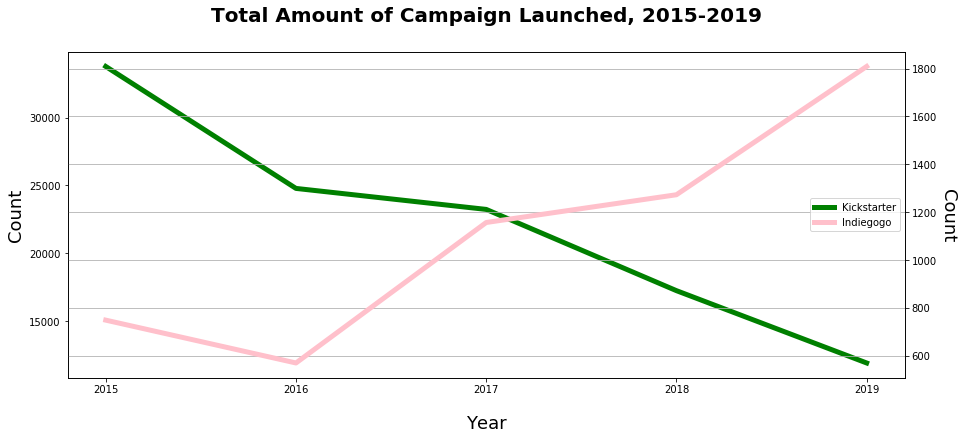

In [173]:
# Plot the results
rcParams['figure.figsize'] = 15,6
fig,ax1 = plt.subplots()
ax2 = ax1.twinx()

# Add two trace to the plot
line1, = ax1.plot(total.Kickstarter, color = 'green', linewidth=5,label='Kickstarter')
line2, = ax2.plot(total.Indiegogo, color = 'pink', linewidth=5, label='Indiegogo')

# Add grid and title
plt.grid(True)
plt.title('Total Amount of Campaign Launched, 2015-2019', size = 20, pad=30, fontweight='bold')

# Add lables for x and y
ax1.set_ylabel('Count', size = 18)
ax2.set_ylabel('Count', size = 18, rotation= 270, labelpad =20)
ax1.set_xlabel('Year', size = 18, labelpad =20)

# Add legend for the plot
plt.legend(handles=[line1,line2], loc='center right')

# - Total Amount of Dollars Raised

In [557]:
# Filter campaign state and create successful and failed data frame for each platform
# Kickstarter 
successful_kick = kickstarter_df[kickstarter_df.State == 'successful']
failed_kick = kickstarter_df[kickstarter_df.State == 'failed']

# Indiegogo
successful_ind = indiegogo_df[indiegogo_df.State == 'successful']
failed_ind = indiegogo_df[indiegogo_df.State == 'failed']

# Display
display(HTML('<h3><center>----------Kickstarter----------</center></h3>'))
display(successful_kick.head(3), failed_kick.head(3))

display(HTML('<h3><center>----------Indiegogo----------</center></h3>'))
display(successful_ind.head(3), failed_ind.head(3))

,Launch Year,Blurb,Total,ID,Name,State,Length,Category
1,2015,We are working on producing our first full-len...,2726,1089621560,Slackline - First Full-Length Record,successful,30,Rock
2,2015,The Salesman! is a fun filled Sci/Fi thriller ...,1341,112008136,The Salesman!,successful,36,Webcomics
7,2015,"On January 22, three comic book self-publisher...",106,1666299284,A Really Awesome Comic Book Critique,successful,21,Events


,Launch Year,Blurb,Total,ID,Name,State,Length,Category
0,2015,Looking to restart my business over with an up...,264,1092131603,BabyGurl's Chocolates and Confections,failed,59,Small Batch
3,2015,I'm sick of not being able to trust what we ea...,420,1918085783,Lady Greens,failed,30,Vegan
4,2015,AstroLabs allow online or distance learning st...,62,1897636385,AstroLabs,failed,30,Space Exploration


,Category,Total,ID,Tagline,Title,Launch Year,Length,State
20489,Phones,343255,1692682,The only alarm clock you will ever need again ...,Shock Clock WakeUp Trainer -Never Hit Snooze A...,2016,44,successful
4622,Home,32568,1948148,Create a warm and beautiful atmosphere in your...,Glow - Levitating lamp,2016,1,successful
24846,Food,15140,1980415,"A gorgeous Mixing Glass for stirred drinks, tw...",Cocktail Mixing Glass & Ebony & Maple Muddlers,2016,1,successful


,Category,Total,ID,Tagline,Title,Launch Year,Length,State
24834,Photography,980,1075054,Help photographer Andrew Kaiser re-purchase mu...,Andrew Kaiser Photography,2015,30,failed
13468,Human Rights,1376,1075281,Help us furnish Naher Aloja Center in Balata ...,"Children of Balata refugees camp, Palestine",2015,18,failed
3785,Video Games,7302,654525,Be the first to colonize the Red Planet in the...,Mission to Mars 2049: A Family Board Game,2015,45,failed


In [167]:
# Calculate the sum of used pledged 
total_successful_kick = pd.DataFrame(data = successful_kick.groupby('Launch Year')['Total'].sum(axis=1))
total_successful_ind = pd.DataFrame(data = successful_ind.groupby('Launch Year')['Total'].sum(axis=1))

# Create a new total dataframe
total_pledged = pd.concat([total_successful_kick['Total'], total_successful_ind['Total']],
                          axis=1, keys=['Kickstarter', 'Indiegogo']).reset_index().T.reset_index(drop=True).T
total_pledged_new = total_pledged.fillna(0)

# Add new column names 
total_pledged_new.columns = ['Year','Kickstarter','Indiegogo']

#total_pledged_new_plot = pd.DataFrame(data = total_pledged_new)
total_pledged_new.set_index("Year", inplace=True)
total_pledged_new.T

/Users/e.kzhou/anaconda3/lib/python3.7/site-packages/ipykernel_launcher.py:7: FutureWarning:

Sorting because non-concatenation axis is not aligned. A future version
of pandas will change to not sort by default.

To accept the future behavior, pass 'sort=False'.

To retain the current behavior and silence the warning, pass 'sort=True'.




Year,2015,2016,2017,2018,2019
Kickstarter,263953148.0,236711560.0,219345892.0,126742851.0,106510236.0
Indiegogo,0.0,390963.0,8364758.0,15894907.0,8010181.0


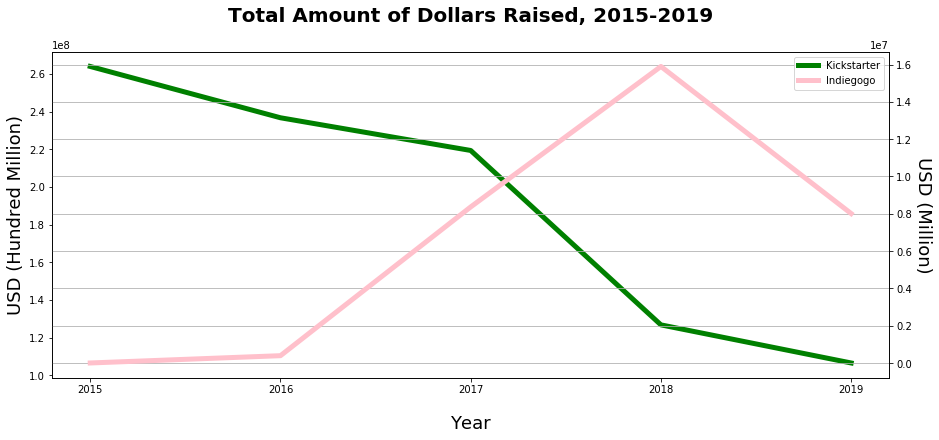

In [168]:
# Plot the founding result 
from matplotlib import rcParams

rcParams['figure.figsize'] = 15,6
fig,ax3 = plt.subplots()
ax4 = ax3.twinx()

# Add two trace to the plot
line3, = ax3.plot(total_pledged_new_plot.Kickstarter, color = 'green',linewidth=5,label='Kickstarter')
line4, = ax4.plot(total_pledged_new.Indiegogo, color = 'pink',linewidth=5, label='Indiegogo')

# Add grid and title
plt.grid(True)
plt.title('Total Amount of Dollars Raised, 2015-2019', size = 20, pad=30, fontweight='bold')

# Add lables for x and y
ax3.set_ylabel('USD (Hundred Million)', size = 18)
ax4.set_ylabel('USD (Million)', size = 18, rotation= 270, labelpad =20)
ax3.set_xlabel('Year', size = 18, labelpad =20)

# Add legend for the plot
plt.legend(handles=[line3,line4], loc='upper right')

# -  Campaign Success Rate

In [36]:
# Summary the success rate in two plateform 
display(HTML('<h3><center>----------Kickstarter----------</center></h3>'))
display(kickstarter_df['State'].value_counts())

display(HTML('<h3><center>----------Indiegogo----------</center></h3>'))
display(indiegogo_df['State'].value_counts())

failed        65814
successful    45127
Name: State, dtype: int64

failed        5543
successful      15
Name: State, dtype: int64

In [174]:
# Plot the comparsion
from plotly.subplots import make_subplots

labels = ['Failed', 'Successful']

# Create subplots: use 'domain' type for Pie subplot
fig = make_subplots(rows=1, cols=(2), specs=[[{'type':'domain'}, {'type':'domain'}]])
fig.add_trace(go.Pie(labels=labels, values=kickstarter_df['State'].value_counts(), name='Kickstarter'),
              1, 1)
fig.add_trace(go.Pie(labels=labels, values=indiegogo_df['State'].value_counts(), name='Indiegogo'),
              1, 2)

# Use `hole` to create a donut-like pie chart
fig.update_traces(hole=.6, hoverinfo='label+name')

fig.update_layout(
    title_text='<b>Campaign Success Rate, 2015-2019</b>',
    # Add annotations in the center of the donut pies.
    annotations=[dict(text='Kickstarter', x=0.15, y=0.5, font_size=20, showarrow=False),
                 dict(text='Indiegogo', x=0.85, y=0.5, font_size=20, showarrow=False)])
fig.show()

# - Campaign Duration Distribution

In [38]:
# The frequency of Kickstarter project last
fig_his_kick = px.histogram(kickstarter_df, x='Length', color='State')
fig_his_kick.update_layout(
    title_text='<b>Histogram of Campaign Duration on Kickstarter</b>', # title of plot
    xaxis_title_text='Campaign Duration', # xaxis label
    yaxis_title_text='Count', # yaxis label

)
fig_his_kick.show()

In [563]:
# The frequency of Indiegogo project last
fig_his_ind = px.histogram(indiegogo_df, x='Length', color='State')
fig_his_ind.update_layout(
    title_text='<b>Histogram of Campaign Duration on Indiegogo</b>', # title of plot
    xaxis_title_text='Campaign Duration', # xaxis label
    yaxis_title_text='Count', # yaxis label

)
fig_his_ind.show()

# - Campagin Fundings 

In [578]:
# Create new column for mean of different type of category
kick_sc_funds = pd.DataFrame(data = successful_kick.groupby('Category')['Total'].mean()).reset_index()
kick_fa_funds = pd.DataFrame(data = failed_kick.groupby('Category')['Total'].mean()).reset_index()
kick_funds_by_category = kick_sc_funds.merge(kick_fa_funds, left_on='Category', right_on='Category',
                                             suffixes=('_Mean_Successful', '_Mean_Failed'))

# Calaute the percentage of two states and create two new columns
kick_funds_by_category['Difference'] = kick_funds_by_category.Total_Mean_Successful - kick_funds_by_category.Total_Mean_Failed

# Conver the float into inteager
kick_funds_by_category.Total_Mean_Successful = kick_funds_by_category.Total_Mean_Successful.astype(int)
kick_funds_by_category.Total_Mean_Failed = kick_funds_by_category.Total_Mean_Failed.astype(int)
kick_funds_by_category.Difference = kick_funds_by_category.Difference.astype(int)

# Display
kick_funds_by_category_plot = kick_funds_by_category.sort_values(by= 'Total_Mean_Successful', ascending = False).iloc[0:32]
kick_funds_by_category_plot.head()


,Category,Total_Mean_Successful,Total_Mean_Failed,Difference
35,Fabrication Tools,219433,3977,215456
13,Camera Equipment,177144,6506,170638
115,Wearables,173310,8212,165097
0,3D Printing,151156,6620,144536
44,Flight,143026,5924,137102


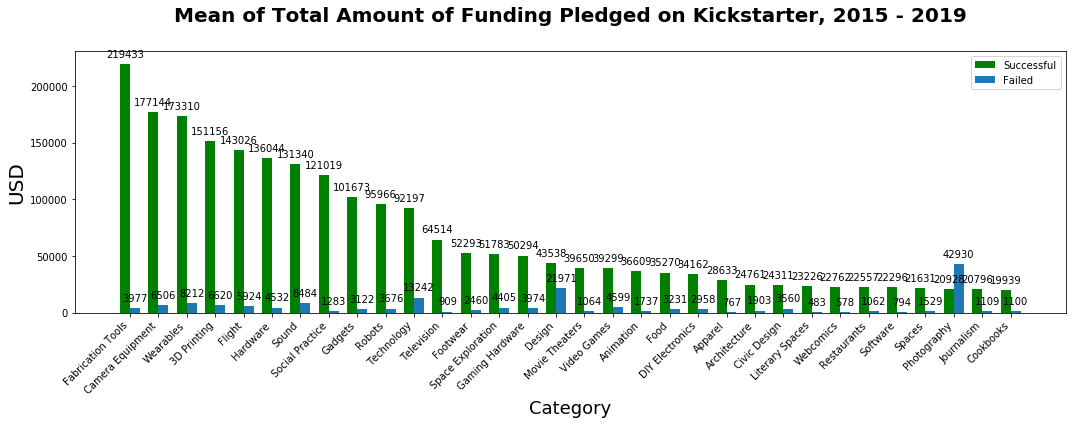

In [579]:
labels = kick_funds_by_category_plot['Category']
kick_sc_means = kick_funds_by_category_plot['Total_Mean_Successful']
kcik_fa_means = kick_funds_by_category_plot['Total_Mean_Failed']

x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, kick_sc_means, width, label='Successful', color = 'Green')
rects2 = ax.bar(x + width/2, kcik_fa_means, width, label='Failed')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('USD', size = 20)
ax.set_xlabel('Category', size = 18)
ax.set_title('Mean of Total Amount of Funding Pledged on Kickstarter, 2015 - 2019', size = 20, pad=30, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, horizontalalignment='right')
ax.legend()

def autolabel(rects):
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0,15), 
                    textcoords="offset points",
                    ha='center', va='top')
autolabel(rects1)
autolabel(rects2)

# Display
fig.tight_layout()
plt.show()

In [562]:
# Create new column for mean of different type of category
ind_sc_funds = pd.DataFrame(data = successful_ind.groupby('Category')['Total'].mean()).reset_index()
ind_fa_funds = pd.DataFrame(data = failed_ind.groupby('Category')['Total'].mean()).reset_index()
ind_funds_by_category = ind_sc_funds.merge(ind_fa_funds, left_on='Category', right_on='Category',
                                             suffixes=('_Mean_Successful', '_Mean_Failed'))

# Calaute the percentage of two states and create two new columns
ind_funds_by_category['Difference'] = ind_funds_by_category.Total_Mean_Successful - ind_funds_by_category.Total_Mean_Failed

# Conver the float into inteager
ind_funds_by_category.Total_Mean_Successful = ind_funds_by_category.Total_Mean_Successful.astype(int)
ind_funds_by_category.Total_Mean_Failed = ind_funds_by_category.Total_Mean_Failed.astype(int)
ind_funds_by_category.Difference = ind_funds_by_category.Difference.astype(int)

# Display
ind_funds_by_category_plot = ind_funds_by_category.sort_values(by= 'Difference', ascending = False)
ind_funds_by_category

,Category,Total_Mean_Successful,Total_Mean_Failed,Difference
0,Energy,14959087,39970,14919116
1,Fashion,2633394,111497,2521896
2,Food,15140,39203,-24063
3,Home,518957,181553,337403
4,Phones,236592,104867,131725
5,Productivity,5941230,133723,5807506
6,Tabletop Games,33586,27522,6063
7,Transportation,69724,147385,-77661
8,Travel,1678217,135036,1543180


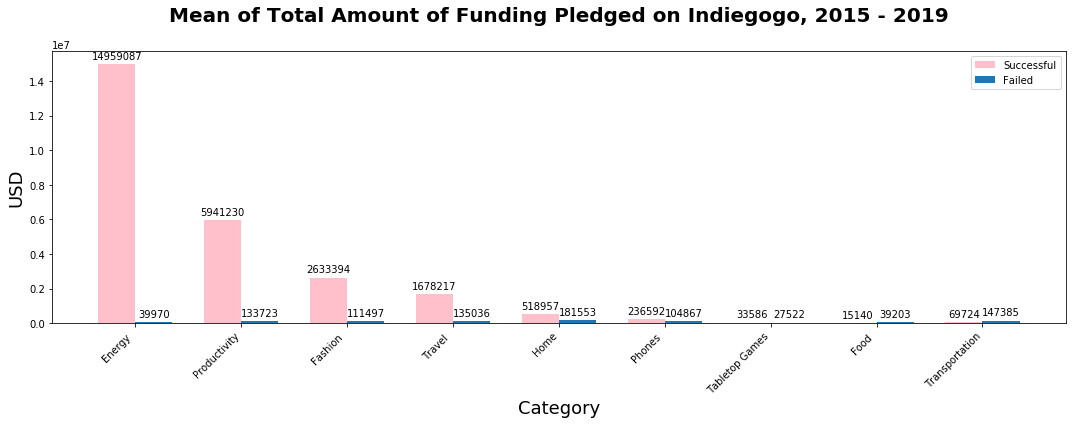

In [565]:
# Indiegogo
# Assign the value to each
labels = ind_funds_by_category_plot['Category']
ind_sc_means = ind_funds_by_category_plot['Total_Mean_Successful']
ind_fa_means = ind_funds_by_category_plot['Total_Mean_Failed']

# Set the plots
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects3 = ax.bar(x - width/2, ind_sc_means, width, label='Successful', color = 'pink')
rects4 = ax.bar(x + width/2, ind_fa_means, width, label='Failed')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_ylabel('USD', size = 18)
ax.set_xlabel('Category', size = 18)
ax.set_title('Mean of Total Amount of Funding Pledged on Indiegogo, 2015 - 2019', size = 20, pad=30, fontweight='bold')

# Edit the ticks
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, horizontalalignment='right')
ax.legend()

# Set the label
def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate('{}'.format(height),
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0,3),
                    textcoords="offset points",
                    ha='center', va='bottom')
autolabel(rects3)
autolabel(rects4)

# Display
fig.tight_layout()
plt.show()

# - Campaign Categories

In [566]:
# Kickstarter 
# Groupby category in successful and failed 
category_kick = pd.DataFrame(data = successful_kick.groupby('Category').agg({'count'}))
failed_category_kick = pd.DataFrame(data = failed_kick.groupby('Category').agg({'count'}))

# Create a new total dataframe
kick_category = pd.concat([category_kick['ID'], failed_category_kick['ID']], 
                           axis=1, keys=['Successful', 'Failed'],sort=True)

# Drop na rows and reset index
kick_category_new = kick_category.reset_index().fillna(0).T.reset_index(drop=True).T

# Rename the column names 
kick_category_new.columns = ['Name', 'Successful', 'Failed']

# Calaute the percentage of two states and create two new columns
kick_category_new['PCSuccess'] = (kick_category_new.Successful) / (kick_category_new.Successful + kick_category_new.Failed)  *  100
kick_category_new['PCFail'] = (kick_category_new.Failed) / (kick_category_new.Successful + kick_category_new.Failed)  *  100
kick_category_new['Total'] = kick_category_new.Successful + kick_category_new.Failed

# Sorting by two columns
kcn_top_fail = kick_category_new.sort_values(by=['PCFail', 'Failed'], ascending = False)
kcn_top_success = kick_category_new.sort_values(by=['PCSuccess', 'Successful'], ascending = False)
kcn_top_total= kick_category_new.sort_values(by= 'Total', ascending = False)

# Display
display(HTML('<h3><center>----------Kickstarter by State----------</center></h3>'))
display(kcn_top_total.head(10), kcn_top_success.head(10), kcn_top_fail.head(10))



,Name,Successful,Failed,PCSuccess,PCFail,Total
152,Web,182,2657,6.41071,93.5893,2839
8,Apps,291,1810,13.8505,86.1495,2101
24,Comedy,774,1270,37.8669,62.1331,2044
106,Playing Cards,1369,618,68.8978,31.1022,1987
123,Restaurants,197,1750,10.1181,89.8819,1947
40,Drama,753,1187,38.8144,61.1856,1940
68,Hip-Hop,233,1704,12.0289,87.9711,1937
39,Documentary,1857,0,100,0,1857
132,Software,159,1673,8.67904,91.321,1832
41,Drinks,289,1522,15.958,84.042,1811


,Name,Successful,Failed,PCSuccess,PCFail,Total
39,Documentary,1857,0,100,0,1857
70,Illustration,1693,0,100,0,1693
19,Children's Books,1526,0,100,0,1526
129,Shorts,1443,0,100,0,1443
25,Comic Books,1264,0,100,0,1264
2,Accessories,1162,0,100,0,1162
30,Country & Folk,1027,0,100,0,1027
95,Nonfiction,1004,0,100,0,1004
54,Fiction,931,0,100,0,931
125,Rock,888,0,100,0,888


,Name,Successful,Failed,PCSuccess,PCFail,Total
34,DIY,0,971,0,100,971
103,Photobooks,0,884,0,100,884
155,Woodworking,0,854,0,100,854
97,People,0,710,0,100,710
105,Places,0,458,0,100,458
56,Fine Art,0,420,0,100,420
17,Candles,0,404,0,100,404
94,Nature,0,385,0,100,385
111,Print,0,362,0,100,362
99,Performances,0,338,0,100,338


In [290]:
# Indiegogo
# Groupby category in successful and failed 
category_ind = pd.DataFrame(data = successful_ind.groupby('Category').agg({'count'}))
failed_category_ind = pd.DataFrame(data = failed_ind.groupby('Category').agg({'count'}))

# Create a new total dataframe
ind_category = pd.concat([category_ind['ID'], failed_category_ind['ID']], 
                           axis=1, keys=['Successful', 'Failed'],sort=True)

# Drop na rows and reset index
ind_category_new = ind_category.reset_index().fillna(0).T.reset_index(drop=True).T

# Rename the column names 
ind_category_new.columns = ['Name', 'Successful', 'Failed']

# Calaute the percentage of two states and create two new columns
ind_category_new['PCSuccess'] = (ind_category_new.Successful) / (ind_category_new.Successful + ind_category_new.Failed)  *  100
ind_category_new['PCFail'] = (ind_category_new.Failed) / (ind_category_new.Successful + ind_category_new.Failed)  *  100
ind_category_new['Total'] = ind_category_new.Successful + ind_category_new.Failed

# Sorting by two columns
icn_top_fail = ind_category_new.sort_values(by=['PCFail', 'Failed'], ascending = False)
icn_top_success = ind_category_new.sort_values(by=['PCSuccess', 'Successful'], ascending = False)
icn_top_total= ind_category_new.sort_values(by= 'Total', ascending = False)

# Display
display(HTML('<h3><center>----------Indiegogo Category by State----------</center></h3>'))
display(icn_top_fail.head(10), icn_top_success.head(10), icn_top_total.head(10))

,Name,Successful,Failed,PCSuccess,PCFail,Total
9,Film,0,305,0,100,305
24,Web Series,0,292,0,100,292
15,Music,0,289,0,100,289
4,Culture,0,271,0,100,271
1,Audio,0,234,0,100,234
26,Writing,0,210,0,100,210
25,Wellness,0,203,0,100,203
3,Comics,0,191,0,100,191
11,Health,0,189,0,100,189
13,Human Rights,0,189,0,100,189


,Name,Successful,Failed,PCSuccess,PCFail,Total
12,Home,3,228,1.2987,98.7013,231
8,Fashion,3,232,1.2766,98.7234,235
16,Phones,2,194,1.02041,98.9796,196
20,Tabletop Games,2,212,0.934579,99.0654,214
6,Energy,1,145,0.684932,99.3151,146
19,Productivity,1,216,0.460829,99.5392,217
21,Transportation,1,236,0.421941,99.5781,237
22,Travel,1,238,0.41841,99.5816,239
10,Food,1,299,0.333333,99.6667,300
0,Art,0,186,0,100,186


,Name,Successful,Failed,PCSuccess,PCFail,Total
9,Film,0,305,0,100,305
10,Food,1,299,0.333333,99.6667,300
24,Web Series,0,292,0,100,292
15,Music,0,289,0,100,289
4,Culture,0,271,0,100,271
22,Travel,1,238,0.41841,99.5816,239
21,Transportation,1,236,0.421941,99.5781,237
8,Fashion,3,232,1.2766,98.7234,235
1,Audio,0,234,0,100,234
12,Home,3,228,1.2987,98.7013,231


In [349]:
# Kickstarter
# Define the values
y1_k = kcn_top_total['Name']
x1_k = kcn_top_total['Failed']
x2_k = kcn_top_total['Successful']

# Put the values into plot
fig = go.Figure()
fig.add_trace(go.Bar(
    y=y1_k,
    x=x1_k,
    name='Failed',
    orientation='h',    
    marker=dict(
        color='rgba(58, 71, 80, 0.6)',
        line=dict(color='rgba(58, 71, 80, 1.0)', width=2 )
    )
))
   
fig.add_trace(go.Bar(
    y=y1_k,
    x=x2_k,
    name='Successful',
    orientation='h',
    marker=dict(
        color='rgba(0, 255, 0, 0.6)',
        line=dict(color='rgba(0, 255, 0, 2.0)', width=2 )
    )
))

# Add title
fig.update_layout(barmode='stack',title_text='<b>Campaign Category Popularity on Kickstarter, 2015-2019</b>', yaxis={'categoryorder':'sum ascending'})

# Display
fig.show()

In [350]:
# Indiegogo
# Define the values
y1 = icn_top_total['Name']
x1 = icn_top_total['Failed']
x2 = icn_top_total['Successful']

# Add the value to the plot
fig = go.Figure()
fig.add_trace(go.Bar(
    y=y1,
    x=x1,
    name='Failed',
    orientation='h',    
    marker=dict(
        color='rgba(58, 71, 80, 0.6)',
        line=dict(color='rgba(58, 71, 80, 1.0)', width=2)
    )
))
   
fig.add_trace(go.Bar(
    y=y1,
    x=x2,
    name='Successful',
    orientation='h',
    marker=dict(
        color='rgba(246, 78, 139, 0.6)',
        line=dict(color='rgba(246, 78, 139, 1.0)', width=2)
    )
))

# Add title
fig.update_layout(barmode='stack',title_text='<b>Campaign Category Popularity on Indiegogo, 2015-2019</b>', yaxis={'categoryorder':'sum ascending'})

# Display
fig.show()

## Successfully Funded Campaign Category Trend

In [89]:
# Group by category and count by year
category_by_year_kick = pd.DataFrame(data = successful_kick.groupby('Category')['Launch Year'].value_counts())
category_by_year_kick.rename(columns = {'Launch Year':'Count'}, inplace = True) 

# Reset the muiltiple index 
category_by_year_kick.reset_index(inplace=True) 

# Sort the value by year 
category_by_year_kick_new = pd.DataFrame(data = category_by_year_kick.sort_values(by=['Launch Year']))

category_by_year_kick_new.head(3)

,Category,Launch Year,Count
0,3D Printing,2015,72
204,Graphic Novels,2015,263
206,Hardware,2015,225


In [88]:
# Indiegogo

# Group by category and count by year
category_by_year_ind = pd.DataFrame(data = successful_ind.groupby('Category')['Launch Year'].value_counts())

# Reset the muiltiple index 
category_by_year_ind.rename(columns = {'Launch Year':'Count'}, inplace = True) 


category_by_year_ind.reset_index(inplace=True)

# Solve the value by year 
category_by_year_ind_new = pd.DataFrame(data = category_by_year_ind.sort_values(by=['Launch Year']))
category_by_year_ind_new.head(3)


,Category,Launch Year,Count
4,Food,2016,1
5,Home,2016,1
8,Phones,2016,1


In [90]:
# Total amount of Successfully funded projects
fig_category_kick_bar = px.bar(category_by_year_kick_new, x='Launch Year', y='Count', color='Category', 
             title='<b>Successfully Funded Campaign Categories Trend on Kickstarter, 2015 - 2019</b>')
fig_category_ind_bar = px.bar(category_by_year_ind_new, x='Launch Year', y='Count', color='Category', 
             title='<b>Successfully Funded Campaign Categories Trend on Indiegogo, 2015 - 2019</b>')

# Display the two plot
fig_category_kick_bar.show()
fig_category_ind_bar.show()

# - Top Words in Campaign Title and Tagline
   - Kickstarter

In [91]:
# Failed Kickstarter - Name
# Extract the words in failed campaigns
failed_name_text_kickstarter = str(failed_kick.Name.values)
failed_name_kickstarter = word_tokenize(failed_name_text_kickstarter)


# Filter the stopwords
failed_filtered_sentence_name_kickstarter = []
for w in failed_name_kickstarter:
    if w not in stop_words:
        failed_filtered_sentence_name_kickstarter.append(w)
print(failed_filtered_sentence_name_kickstarter)

# Remove all tokens that are not alphabetic
failed_name_words = [word for word in failed_filtered_sentence_name_kickstarter if word.isalpha()]

# Check the Frequency distributions
failed_name_kickstarter = nltk.FreqDist(w.lower() for w in failed_name_words)
failed_name_kickstarter.items()

['[', '``', 'BabyGurl', "'s", 'Chocolates', 'Confections', "''", "'Lady", 'Greens', "'", "'AstroLabs", "'", '...', "'", 'e-Pitchball', 'Fund', 'Raiser', '-', 'Funds', 'prototype', '...', '(', ')', "'", "'", 'A', 'mouse', 'warm', 'hands', 'winter', "'", "'Kill", ',', 'Die', 'Survive', "'", ']']


dict_items([('babygurl', 1), ('chocolates', 1), ('confections', 1), ('greens', 1), ('fund', 1), ('raiser', 1), ('funds', 1), ('prototype', 1), ('a', 1), ('mouse', 1), ('warm', 1), ('hands', 1), ('winter', 1), ('die', 1), ('survive', 1)])

In [92]:
# Failed Kickstarter - Blurb
# Conver the blurb into string 
failed_blurb_text_kickstarter = str(failed_kick.Blurb.values)
failed_blurb_kickstarter = word_tokenize(failed_blurb_text_kickstarter)

#print(word_tokenize(text))

# Filter the stopwords
failed_filtered_sentence_blurb_kickstarter = []
for w in failed_blurb_kickstarter:
    if w not in stop_words:
        failed_filtered_sentence_blurb_kickstarter.append(w)
print(failed_filtered_sentence_blurb_kickstarter)

# Remove all tokens that are not alphabetic
failed_blurb_words = [word for word in failed_filtered_sentence_blurb_kickstarter if word.isalpha()]
failed_blurb_kickstarter = nltk.FreqDist(w.lower() for w in failed_blurb_words)
print(failed_blurb_kickstarter.items())


['[', "'Looking", 'restart', 'business', 'upgraded', 'kitchen', 'equipment', 'well', 'using', 'higher', 'quality', 'ingredients', '.', "'", '``', 'I', "'m", 'sick', 'able', 'trust', 'eat', '-', 'LadyGreens', 'world', 'trust', 'healthy', 'sustainable', '.', "''", "'AstroLabs", 'allow', 'online', 'distance', 'learning', 'students', 'perform', 'cool', 'astronomy', 'labs', 'anywhere', '!', "'", '...', "'", 'A', 'hands-on', 'physical', 'game', '...', 'bit', 'like', 'Pinball', '...', 'definitely', 'NOT', 'PINBALL', '!', "'", "'", 'I', 'designed', 'mouse', 'generate', 'heat', ',', 'solve', 'problem', 'cold', 'hands', 'winter', ',', 'safe', 'easy', 'use', '.', "'", '``', 'This', 'horror', 'short', 'film', 'school', 'camp', 'child', 'goes', 'missing', "'s", 'Mike', 'Tom', 'kill', ',', 'die', 'survive', 'killer', "''", ']']


dict_items([('restart', 1), ('business', 1), ('upgraded', 1), ('kitchen', 1), ('equipment', 1), ('well', 1), ('using', 1), ('higher', 1), ('quality', 1), ('ingredients', 1), ('i', 2), ('sick', 1), ('able', 1), ('trust', 2), ('eat', 1), ('ladygreens', 1), ('world', 1), ('healthy', 1), ('sustainable', 1), ('allow', 1), ('online', 1), ('distance', 1), ('learning', 1), ('students', 1), ('perform', 1), ('cool', 1), ('astronomy', 1), ('labs', 1), ('anywhere', 1), ('a', 1), ('physical', 1), ('game', 1), ('bit', 1), ('like', 1), ('pinball', 2), ('definitely', 1), ('not', 1), ('designed', 1), ('mouse', 1), ('generate', 1), ('heat', 1), ('solve', 1), ('problem', 1), ('cold', 1), ('hands', 1), ('winter', 1), ('safe', 1), ('easy', 1), ('use', 1), ('this', 1), ('horror', 1), ('short', 1), ('film', 1), ('school', 1), ('camp', 1), ('child', 1), ('goes', 1), ('missing', 1), ('mike', 1), ('tom', 1), ('kill', 1), ('die', 1), ('survive', 1), ('killer', 1)])

In [93]:
# Successful Kickstarter - Name 
# For title 
title_text_kickstarter = str(successful_kick.Name.values)
title_kickstarter = word_tokenize(title_text_kickstarter)
#print(word_tokenize(text))

# Filter the stopwords
filtered_sentence_title_kickstarter = []
for w in title_kickstarter:
    if w not in stop_words:
        filtered_sentence_title_kickstarter.append(w)
print(filtered_sentence_title_kickstarter)

# Remove all tokens that are not alphabetic
title_words = [word for word in filtered_sentence_title_kickstarter if word.isalpha()]

# Frequency distributions
title_kickstarter = nltk.FreqDist(w.lower() for w in title_words)
print(title_kickstarter.items())


['[', "'Slackline", '-', 'First', 'Full-Length', 'Record', "'", "'The", 'Salesman', '!', "'", "'", 'A', 'Really', 'Awesome', 'Comic', 'Book', 'Critique', "'", '...', "'BLOCKS", '!', 'Julius', "Caesar'", "'Temp-pro", '-', 'Temperature', 'Regulated', 'Weighted', 'Blanket', "'", "'APEX", "'", ']']


dict_items([('first', 1), ('record', 1), ('salesman', 1), ('a', 1), ('really', 1), ('awesome', 1), ('comic', 1), ('book', 1), ('critique', 1), ('julius', 1), ('temperature', 1), ('regulated', 1), ('weighted', 1), ('blanket', 1)])

In [96]:
# Successful Kickstarter - Blurb
# Conver the blurb into string 
blurb_text_kickstarter = str(successful_kick.Blurb.values)
blurb_kickstarter = word_tokenize(blurb_text_kickstarter)

#print(word_tokenize(text))

# Filter the stopwords
filtered_sentence_blurb_kickstarter = []
for w in blurb_kickstarter:
    if w not in stop_words:
        filtered_sentence_blurb_kickstarter.append(w)
print(filtered_sentence_blurb_kickstarter)

# Remove all tokens that are not alphabetic
blurb_words = [word for word in filtered_sentence_blurb_kickstarter if word.isalpha()]

# Check the Frequency distributions
blurb_kickstarter = nltk.FreqDist(w.lower() for w in blurb_words)
print(blurb_kickstarter.items())

['[', "'We", 'working', 'producing', 'first', 'full-length', 'record', 'producer', 'Lee', 'Dyess', 'Georgia', ';', 'following', 'first', 'EP', ',', '``', 'Hang', 'Loose', "''", '.', "'", "'The", 'Salesman', '!', 'fun', 'filled', 'Sci/Fi', 'thriller', 'set', 'futuristic', 'wasteland', '.', 'HARDCOVER', "EDITION'", "'On", 'January', '22', ',', 'three', 'comic', 'book', 'self-publishers', 'work', 'professionally', 'critiqued', 'established', 'industry', 'creators', '!', "'", '...', "'BLOCKS", '!', 'Julius', 'Caesar', 'PC', '/', 'Mac', 'version', 'classic', 'Columbia', 'Block', 'wargame', '.', 'Play', 'vs', 'AI', 'multiplayer', 'vs', 'friends', 'steam', '!', "'", "'One", 'kind', ':', 'temperature', 'regulated', 'weighted', 'blanket', '.', 'Feel', 'comfortable', ',', 'feel', 'happier', '.', "'", "'Short", 'Thesis', 'Film', "'", ']']
dict_items([('working', 1), ('producing', 1), ('first', 2), ('record', 1), ('producer', 1), ('lee', 1), ('dyess', 1), ('georgia', 1), ('following', 1), ('ep', 1

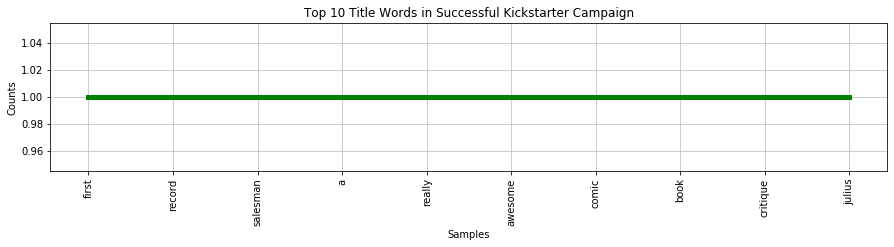

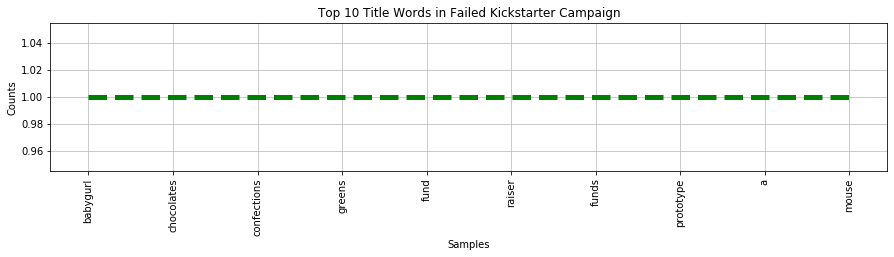

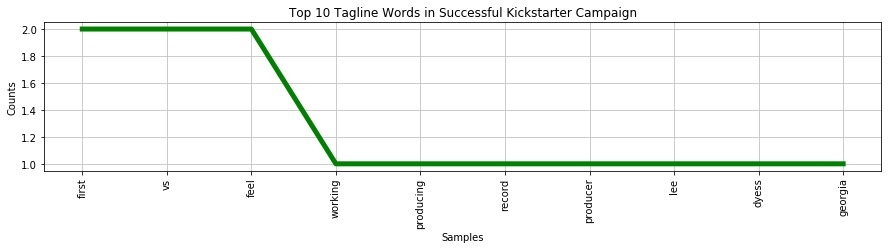

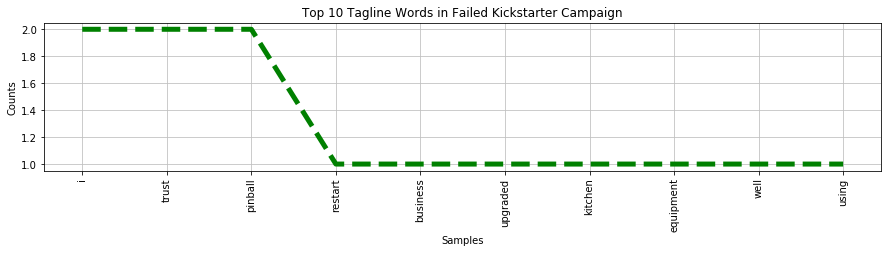

In [95]:
# Plot the top ten words in title in kickstarter
# Successful title
plt.subplot(2, 1, 1)
title_kickstarter.plot(10, title='Top 10 Title Words in Successful Kickstarter Campaign', linewidth=5, c='g')

# Successful title
plt.subplot(2, 1, 1)
failed_name_kickstarter.plot(10,  title='Top 10 Title Words in Failed Kickstarter Campaign', linestyle = '--',linewidth=5, c='g')
plt.show()

# Plot the top ten words in blurb in kickstarter
# Successful title
plt.subplot(2, 1, 1)
blurb_kickstarter.plot(10, title='Top 10 Tagline Words in Successful Kickstarter Campaign', linewidth=5, c='g')

# Failed blurb
plt.subplot(2, 1, 1)
failed_blurb_kickstarter.plot(10, title='Top 10 Tagline Words in Failed Kickstarter Campaign', linestyle = '--',linewidth=5, c='g')
plt.show()

- Indiegogo

In [101]:
# For failed Indiegogo -Title
# Convert the title text into string
failed_title_text_indiegogo = str(failed_ind.Title.values)
failed_title_indiegogo = word_tokenize(failed_title_text_indiegogo)

# Filter the stopwords
failed_filtered_sentence_title_indiegogo = []
for w in failed_title_indiegogo:
    if w not in stop_words:
        failed_filtered_sentence_title_indiegogo.append(w)
print(failed_filtered_sentence_title_indiegogo)

# remove all tokens that are not alphabetic
failed_title_words = [word for word in failed_filtered_sentence_title_indiegogo if word.isalpha()]

failed_title_indiegogo = nltk.FreqDist(w.lower() for w in failed_title_words)
failed_title_indiegogo.items()

['[', "'Andrew", 'Kaiser', 'Photography', "'", "'Children", 'Balata', 'refugees', 'camp', ',', "Palestine'", "'Mission", 'Mars', '2049', ':', 'A', 'Family', 'Board', 'Game', "'", '...', '``', 'Eugene', "'s", 'first', 'poetry', 'book', ',', 'illustrations', '!', "''", '``', 'Euphoria', "'s", '2020', 'Villainous', 'Calendar', "''", "'Classical", 'Sundays', 'NEEDS', 'YOUR', 'HELP', '!', "'", ']']


dict_items([('kaiser', 1), ('photography', 1), ('balata', 1), ('refugees', 1), ('camp', 1), ('mars', 1), ('a', 1), ('family', 1), ('board', 1), ('game', 1), ('eugene', 1), ('first', 1), ('poetry', 1), ('book', 1), ('illustrations', 1), ('euphoria', 1), ('villainous', 1), ('calendar', 1), ('sundays', 1), ('needs', 1), ('your', 1), ('help', 1)])

In [102]:
# For failed Indiegogo -Taline
# Conver the blurb into string 
failed_tagline_text_indiegogo = str(failed_ind.Tagline.values)
failed_tagline_indiegogo = word_tokenize(failed_tagline_text_indiegogo)

#print(word_tokenize(text))

# Filter the stopwords
failed_filtered_sentence_tagline_indiegogo = []
for w in failed_tagline_indiegogo:
    if w not in stop_words:
        failed_filtered_sentence_tagline_indiegogo.append(w)
print(failed_filtered_sentence_tagline_indiegogo)

# remove all tokens that are not alphabetic
failed_tagline_words = [word for word in failed_filtered_sentence_tagline_indiegogo if word.isalpha()]

# Frequency distributions
failed_tagline_indiegogo = nltk.FreqDist(w.lower() for w in failed_tagline_words)
failed_tagline_indiegogo.items()



['[', "'Help", 'photographer', 'Andrew', 'Kaiser', 're-purchase', 'much', 'needed', 'equipment', 'car', 'break-in', '.', "'", "'Help", 'us', 'furnish', 'Naher', 'Aloja', 'Center', 'Balata', 'refugees', "camp'", "'Be", 'first', 'colonize', 'Red', 'Planet', 'new', 'family', 'board', "game'", '...', "'Help", 'self-publish', 'book', '!', '21', 'poems', '21', 'illustrations', 'Sachiko', 'Shigeta', '.', "'", '``', 'Euphoria', "'s", '2020', 'Cosplay', 'Calendar', 'features', 'never', 'seen', 'photos', 'classic', 'Villainous', 'characters', '.', "''", "'MAKING", 'CLASSICAL', 'MUSIC', 'GREAT', 'AGAIN', '!', "'", ']']


dict_items([('photographer', 1), ('andrew', 1), ('kaiser', 1), ('much', 1), ('needed', 1), ('equipment', 1), ('car', 1), ('us', 1), ('furnish', 1), ('naher', 1), ('aloja', 1), ('center', 1), ('balata', 1), ('refugees', 1), ('first', 1), ('colonize', 1), ('red', 1), ('planet', 1), ('new', 1), ('family', 1), ('board', 1), ('book', 1), ('poems', 1), ('illustrations', 1), ('sachiko', 1), ('shigeta', 1), ('euphoria', 1), ('cosplay', 1), ('calendar', 1), ('features', 1), ('never', 1), ('seen', 1), ('photos', 1), ('classic', 1), ('villainous', 1), ('characters', 1), ('classical', 1), ('music', 1), ('great', 1), ('again', 1)])

In [103]:
# For succesful Indiegogo - Title
# Conver the title into string
title_text_indiegogo = str(successful_ind.Title.values)
title_indiegogo = word_tokenize(title_text_indiegogo)
#print(word_tokenize(text))

# Filter the stopwords
filtered_sentence_title_indiegogo = []
for w in title_indiegogo:
    if w not in stop_words:
        filtered_sentence_title_indiegogo.append(w)
print(filtered_sentence_title_indiegogo)

# remove all tokens that are not alphabetic
ind_words = [word for word in filtered_sentence_title_indiegogo if word.isalpha()]

# Frequency distributions
title_indiegogo  = nltk.FreqDist(w.lower() for w in ind_words)
title_indiegogo.items()

['[', "'Shock", 'Clock', 'WakeUp', 'Trainer', '-Never', 'Hit', 'Snooze', "Again'", "'Glow", '-', 'Levitating', 'lamp', "'", "'Cocktail", 'Mixing', 'Glass', '&', 'Ebony', '&', 'Maple', "Muddlers'", "'ZeTime", ':', 'hybrid', 'smartwatch', 'hands', "screen'", "'ClickPack", 'Pro', '-', 'A', 'Functional', 'Anti-theft', "BackPack'", "'VOLTA", 'Magnetic', 'Adapter', '-', 'Charge', 'ANY', 'Device', '!', "'", "'UniLid", ':', 'One', 'Lid', '.', 'Fits', 'All', '.', 'Lifetime', 'Warranty', '.', "'", "'Flow", 'Hive', "2'", "'Cardlax", '-', 'Thinnest', 'Electric', 'Card', "Massager'", "'Miles", 'Mini', 'Performance', 'Electric', "Skateboard'", "'Party", 'Backstory', 'Generator', '5e', 'Other', "Systems'", "'Act2", ':', 'Undergrowth', 'Birth', 'Blight', 'Root', "Terrain'", '``', 'World', "'s", 'first', '3D', 'Wooden', 'World', 'Map', "''", "'SMART", 'BELT', '3.0', '-', 'THE', 'MOST', 'FUNDED', "ACCESSORY'", "'Philips", 'PicoPix', 'Max', '-', '1080p', 'Full', 'HD', 'Pico', 'Projector', "'", ']']


dict_items([('clock', 1), ('wakeup', 1), ('trainer', 1), ('hit', 1), ('snooze', 1), ('levitating', 1), ('lamp', 1), ('mixing', 1), ('glass', 1), ('ebony', 1), ('maple', 1), ('hybrid', 1), ('smartwatch', 1), ('hands', 1), ('pro', 1), ('a', 1), ('functional', 1), ('magnetic', 1), ('adapter', 1), ('charge', 1), ('any', 1), ('device', 1), ('one', 1), ('lid', 1), ('fits', 1), ('all', 1), ('lifetime', 1), ('warranty', 1), ('hive', 1), ('thinnest', 1), ('electric', 2), ('card', 1), ('mini', 1), ('performance', 1), ('backstory', 1), ('generator', 1), ('other', 1), ('undergrowth', 1), ('birth', 1), ('blight', 1), ('root', 1), ('world', 2), ('first', 1), ('wooden', 1), ('map', 1), ('belt', 1), ('the', 1), ('most', 1), ('funded', 1), ('picopix', 1), ('max', 1), ('full', 1), ('hd', 1), ('pico', 1), ('projector', 1)])

In [105]:
# For succesful Indiegogo - Tagline
# Conver the tagline into string 
tagline_text_indiegogo = str(successful_ind.Tagline.values)
tagline_indiegogo = word_tokenize(tagline_text_indiegogo)

# print(word_tokenize(text))

# Filter the stopwords
filtered_sentence_tagline_indiegogo = []
for w in tagline_indiegogo:
    if w not in stop_words:
        filtered_sentence_tagline_indiegogo.append(w)
print(filtered_sentence_tagline_indiegogo)

# Remove all tokens that are not alphabetic
tagline_words = [word for word in filtered_sentence_tagline_indiegogo if word.isalpha()]

# Frequency distributions
tagline_indiegogo = nltk.FreqDist(w.lower() for w in tagline_words)
tagline_indiegogo.items()

['[', "'The", 'alarm', 'clock', 'ever', 'need', '-', 'condition', 'wake', 'early', '!', "'", "'Create", 'warm', 'beautiful', 'atmosphere', 'space', 'glow', ',', 'contemporary', 'levitating', 'lamp', '.', "'", "'", 'A', 'gorgeous', 'Mixing', 'Glass', 'stirred', 'drinks', ',', 'two', 'premium', 'Muddlers', 'press', 'herbs', ',', 'sugar', ',', '&', 'fruit', '.', "'", "'Proudly", 'designed', 'Switzerland', ',', 'perfect', 'smartwatch', 'blending', 'classic', 'design', 'smart', "features'", "'The", 'ClickPack', 'Pro', 'anti-theft', 'backpack', 'combine', 'security', ',', 'storage', ',', 'convenience', ',', 'comfort', 'beauty', '.', "'", "'Transform", 'Micro', 'USB', 'cables', 'Magnetic', 'USB', 'C', ',', 'Micro', 'USB', 'Lightning', '(', 'Apple', ')', 'Cable', '!', "'", "'Universal", 'lid', 'fits', 'shapes', '&', 'sizes', 'food', 'tracking', '.', "'", "'Honey", 'tap', 'directly', "beehive'", "'Cardlax", 'thinnest', 'EMS', 'credit', 'card', 'massager', 'within', '4.7mm', '.', 'Take', 'anywhe

dict_items([('alarm', 1), ('clock', 1), ('ever', 1), ('need', 1), ('condition', 1), ('wake', 1), ('early', 1), ('warm', 1), ('beautiful', 1), ('atmosphere', 1), ('space', 1), ('glow', 1), ('contemporary', 1), ('levitating', 1), ('lamp', 1), ('a', 1), ('gorgeous', 1), ('mixing', 1), ('glass', 1), ('stirred', 1), ('drinks', 1), ('two', 1), ('premium', 1), ('muddlers', 1), ('press', 1), ('herbs', 1), ('sugar', 1), ('fruit', 1), ('designed', 1), ('switzerland', 1), ('perfect', 1), ('smartwatch', 1), ('blending', 1), ('classic', 1), ('design', 1), ('smart', 3), ('clickpack', 1), ('pro', 1), ('backpack', 1), ('combine', 1), ('security', 1), ('storage', 1), ('convenience', 1), ('comfort', 1), ('beauty', 1), ('micro', 2), ('usb', 3), ('cables', 1), ('magnetic', 1), ('c', 1), ('lightning', 1), ('apple', 1), ('cable', 1), ('lid', 1), ('fits', 1), ('shapes', 1), ('sizes', 1), ('food', 1), ('tracking', 1), ('tap', 1), ('directly', 1), ('thinnest', 1), ('ems', 1), ('credit', 1), ('card', 1), ('mass

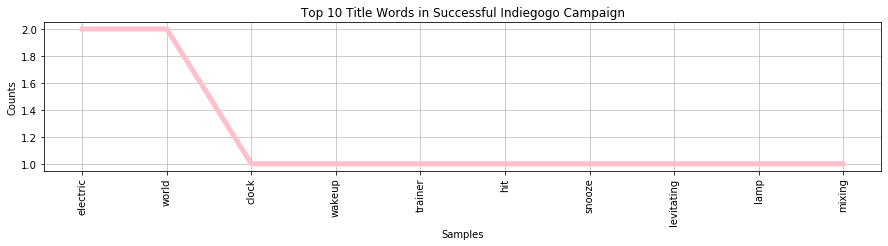

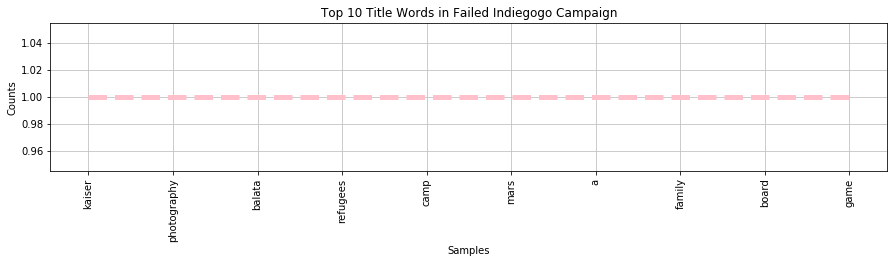

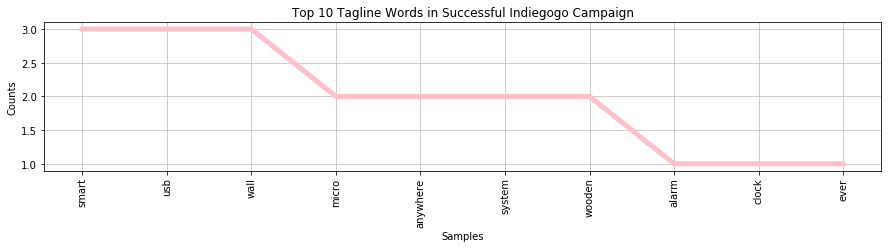

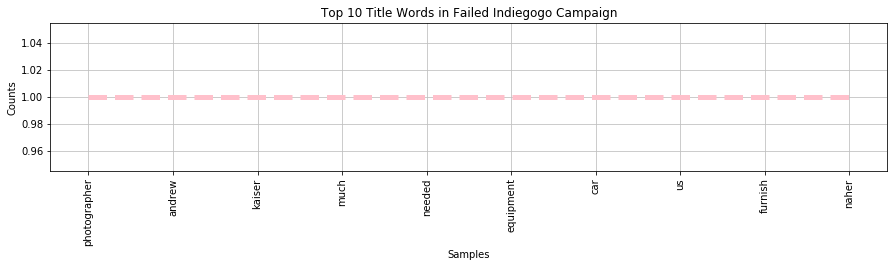

In [104]:
# Plot the top ten words in title at Indiegogo
plt.subplot(2, 1, 1)
title_indiegogo.plot(10, title='Top 10 Title Words in Successful Indiegogo Campaign', 
                     linewidth=5, c='pink')
plt.subplot(2, 1, 1)
failed_title_indiegogo.plot(10, title='Top 10 Title Words in Failed Indiegogo Campaign', 
                            linestyle = '--', linewidth=5, c='pink')

# Plot the top ten words in tagline at Indiegogo
plt.subplot(2, 1, 1)
tagline_indiegogo.plot(10, title='Top 10 Tagline Words in Successful Indiegogo Campaign', 
                       linewidth=5,c='pink')
plt.subplot(2, 1, 1)
failed_tagline_indiegogo.plot(10, title='Top 10 Title Words in Failed Indiegogo Campaign',
                            linestyle = '--', linewidth=5, c='pink')
plt.show()

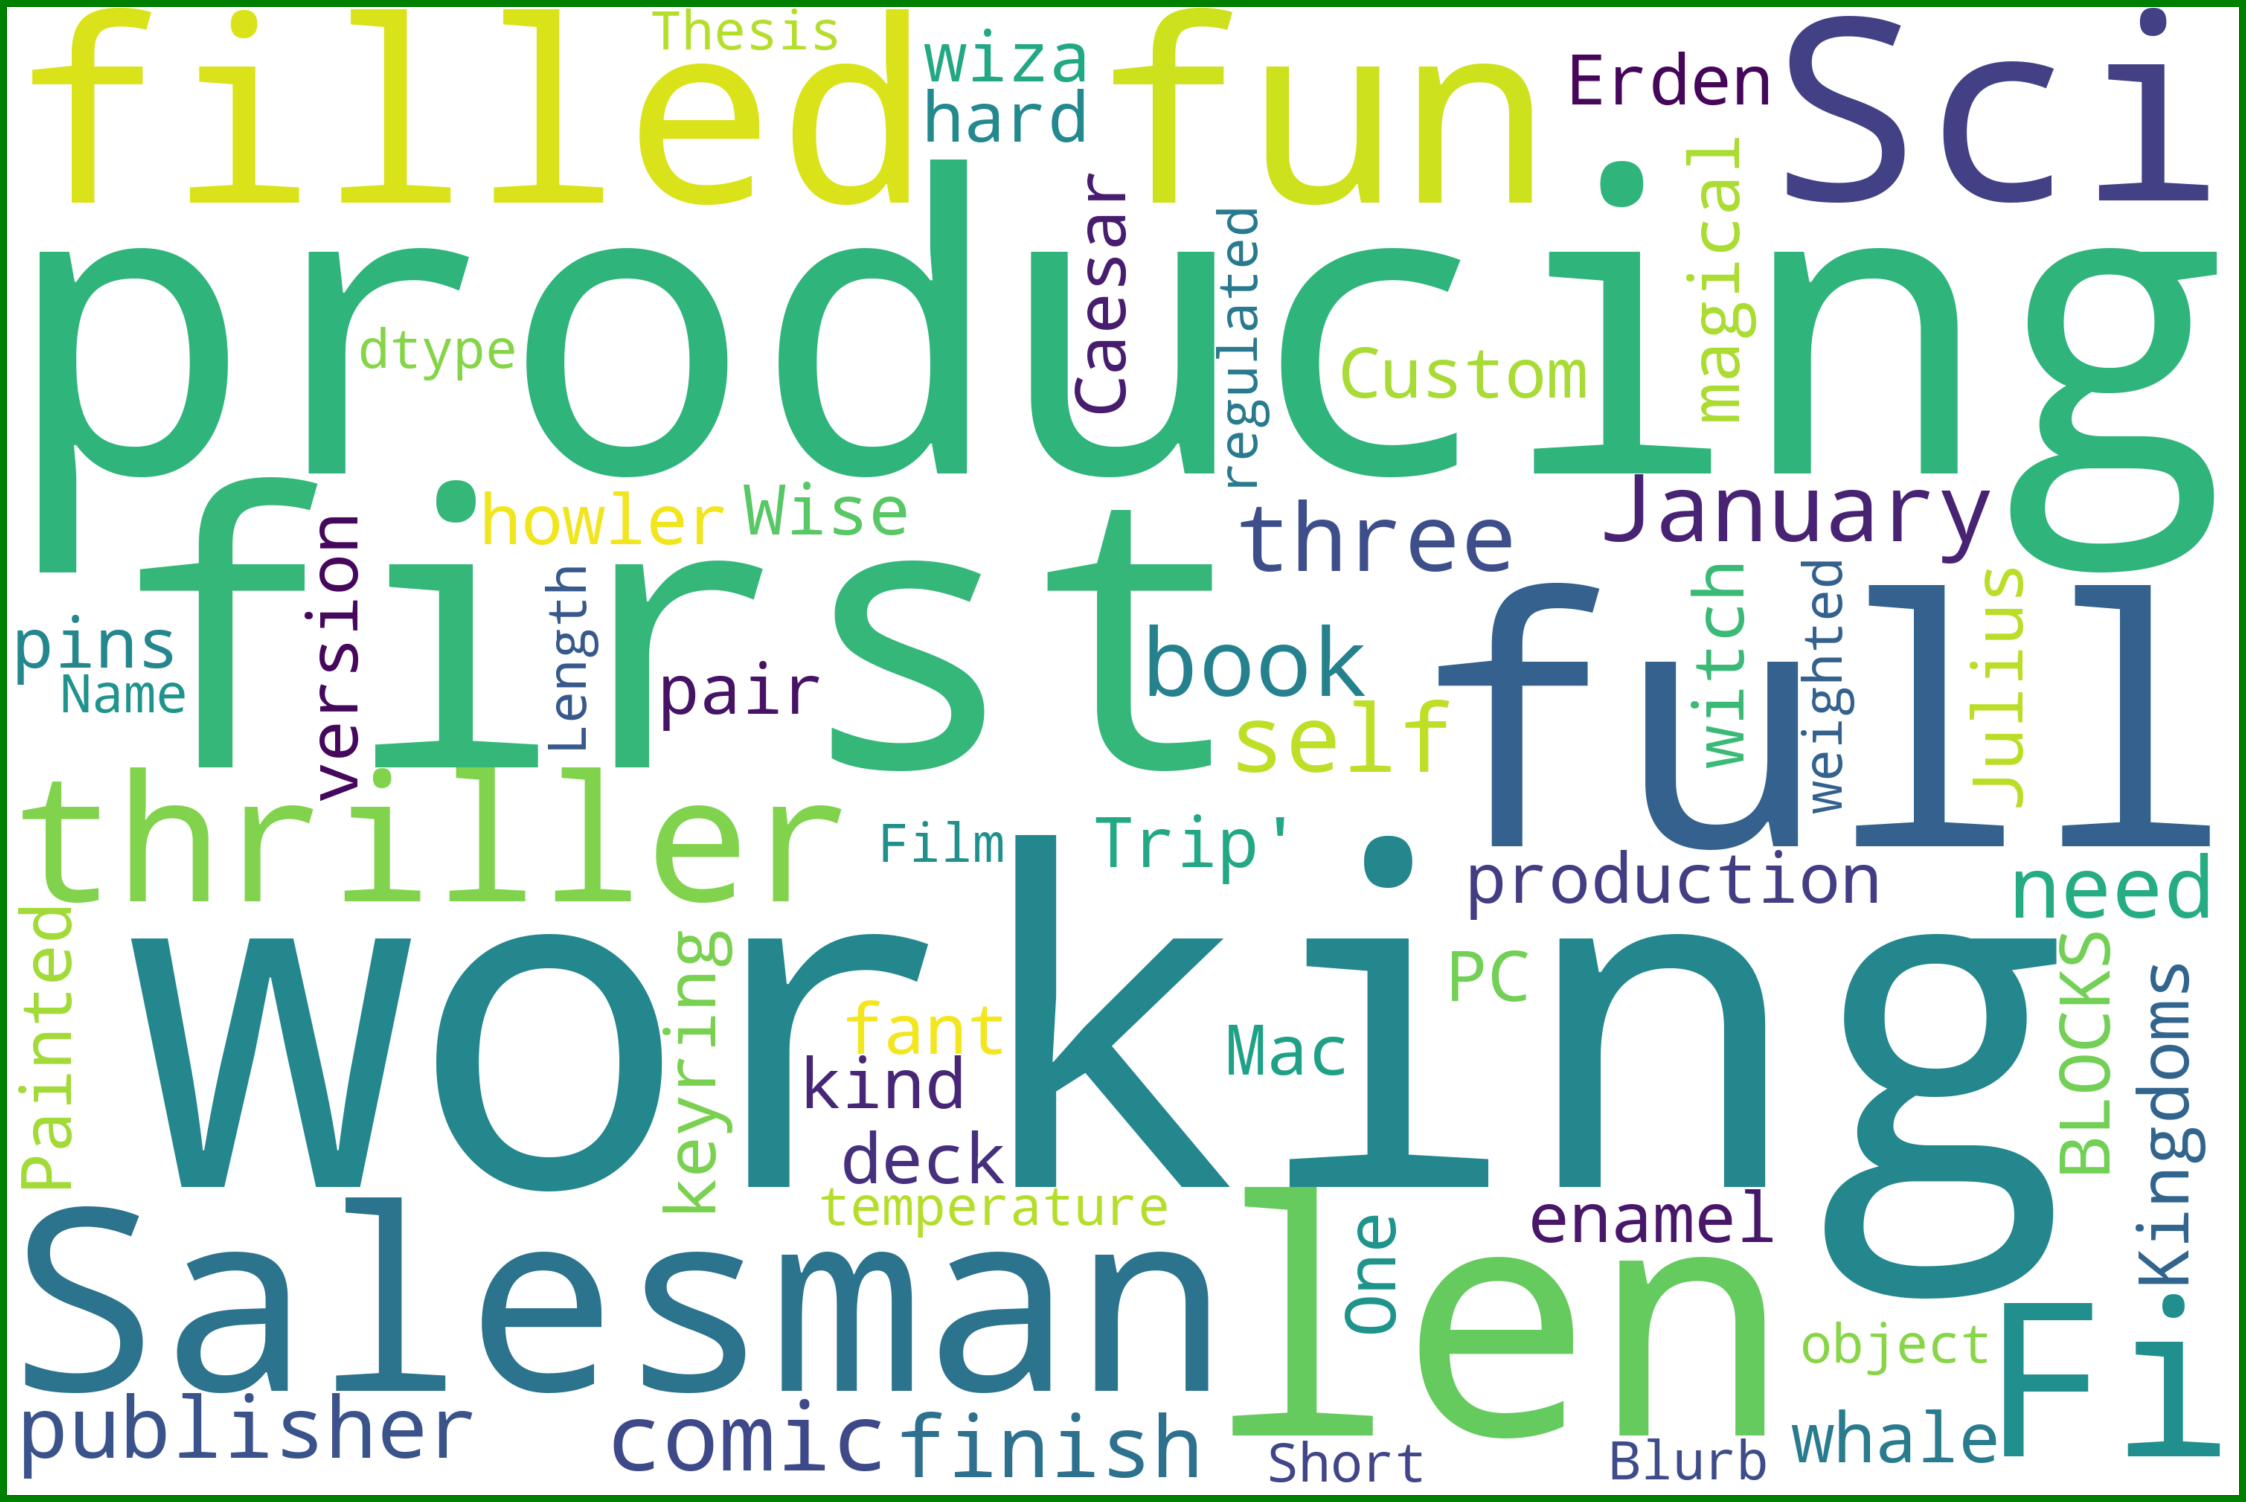

In [351]:
# Create the word cloud for Kickstarter
# Setthe size and colour 
wordcloud_kick = WordCloud(
    width = 3000,
    height = 2000,
    background_color = 'white',
    stopwords = STOPWORDS).generate(str(object = successful_kick['Name' and 'Blurb']))

fig = plt.figure(
    figsize = (40, 30),
    facecolor = 'g',
    edgecolor = 'b')
plt.imshow(wordcloud_kick, interpolation = 'bilinear')

# Trun off the axis
plt.axis('off')

# Display
plt.show()

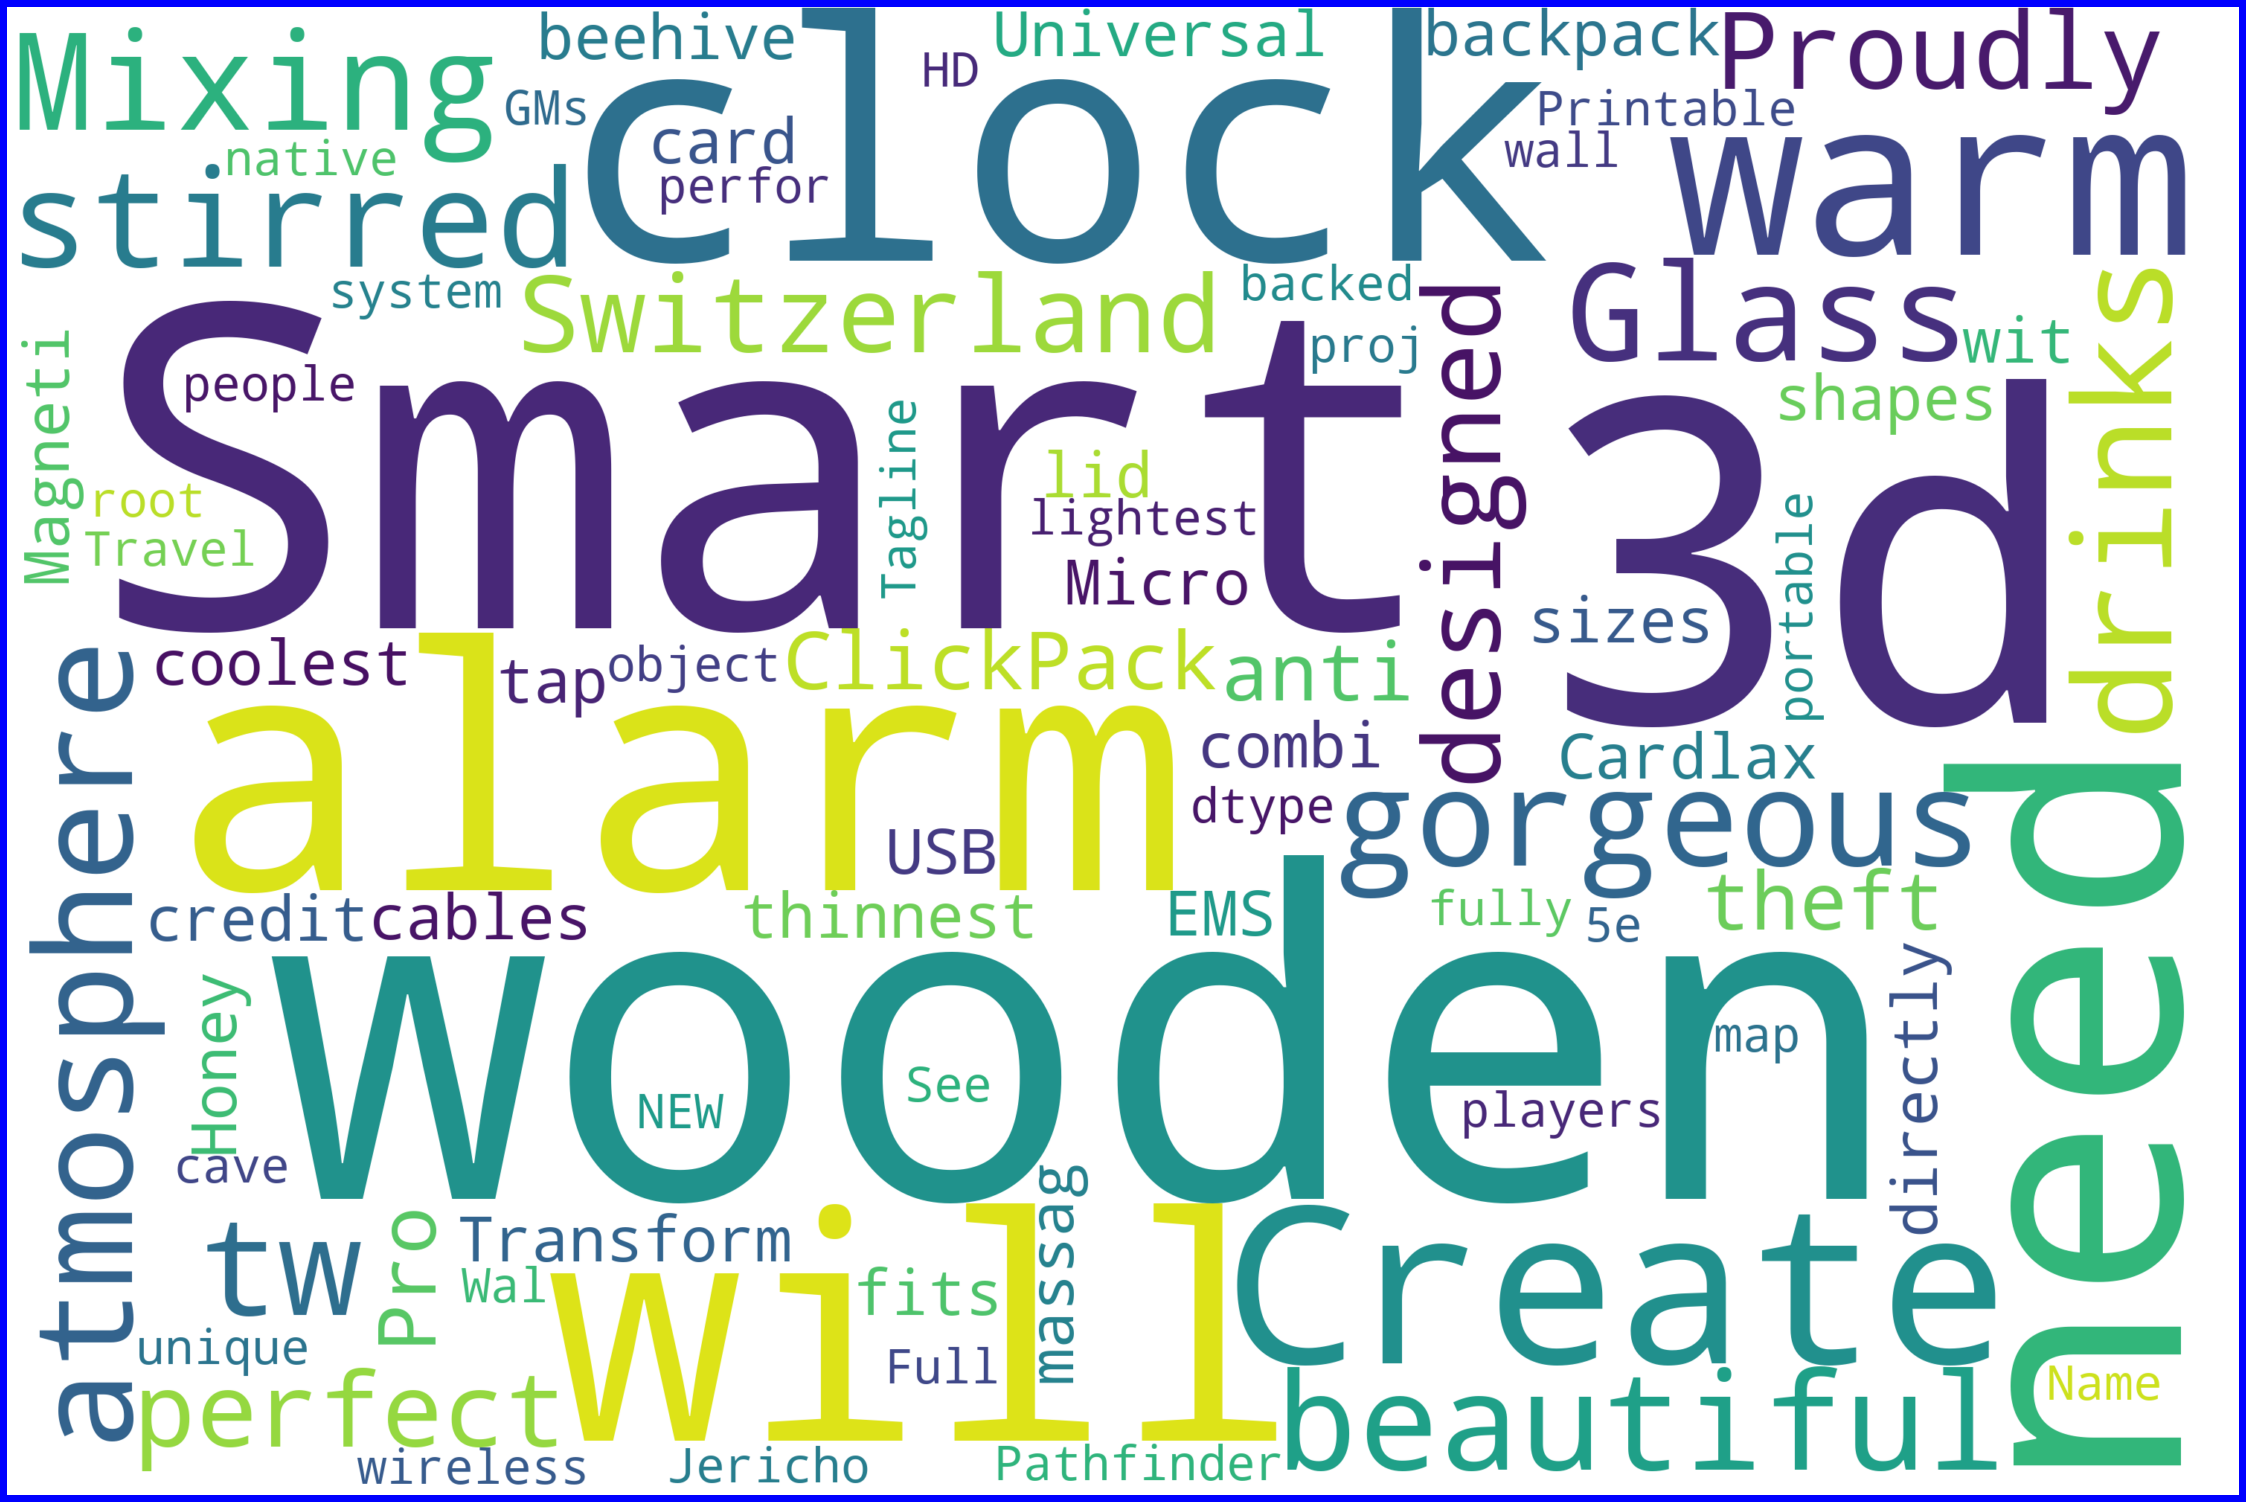

In [106]:
# Create the word cloud for Indiegogo 
# Set the size and colour 

wordcloud = WordCloud(
    width = 3000,
    height = 2000,
    background_color = 'white',
    stopwords = STOPWORDS).generate(str(object = successful_ind['Title' and 'Tagline']))

# Create the figure 
fig = plt.figure(
    figsize = (40, 30),
    facecolor = 'b',
    edgecolor = 'b')

plt.imshow(wordcloud, interpolation = 'bilinear')

# Trun off the axis
plt.axis('off')

# Display 
plt.show()

# Data Cleaning and Pre-Processing

The data cleaning process is complicated, as the data was scraped from two websites. So while some cleaning work is shared, most of it is different. Besides,  the text columns that use natural language processing techniques will also be explained separately. So the cleaning steps will be divided into four steps.

#### 1. Shared Steps: 

<li> Download the zipped file. </li> 
<li> Unzip, open, and read all the raw data tables into the Jupyter notebook.</li> 
<li> Get the original shape of the table. </li> 
<li> Using **Project ID** as the unique value for removing duplicates. </li> 
<li> Check the NA value in the table, remove columns that dominate by NA values. </li> 

#### 2. Kickstarter: 
<ul>
<li> Convert the 10 digits timestamp to proper year-month-day display.</li> 
<li> Convert the new time to string and calculate the length of the campaign. </li> 
<li> Filter date and year to keep. </li> 
<li> Clean the category column by split and removing not relevant text and punctuations. </li> 
</ul>


#### 3. Indiegogo:
   <ul>
       <li> Reset the reading path from another directory. </li> 
<li> Split the data/time column.</li> 
         <li> Convert the new time to string and calculate the length of the campaign. </li> 
         <li> Filter date and year to keep. </li> 
         <li> Create a new column for categorizing funds_raised_percent numerical value into a string value.</li> 
         <li> Split the category and set the first category as primary.</li> 
    </ul>


<li> Drop all the old columns. </li> 
<li> Rename the column names.  </li> 
<li> Before starting to use the table, check the index and columns, and print out the table for later reference. </li> 



#### 4. Text Data for Natural Language Processing:
<ul>
<li> Locate the text value from the dataframe. </li> 
<li> Filter stop words.</li> 
<li> Remove punctuation.</li> 
</ul>


# Conclusions  and Predictions


#### Total 
In this section, the numbers present an overview of the two platforms, including the total number of campaigns launched and the total amount of funds raised.

Kickstarter has seen a steady decline over the past five years in both the number of campaigns launched and the total funds raised by successful projects.

In contrast, Indiegogo’s total number of projects launched dipped in 2016 but quickly recovered in 2017. Since then, both the number of projects and the amount of funding have continued to grow. In addition, the total funding raised by successful projects peaked in 2018.

The results suggest that as the Indiegogo archive continues to grow, Kickstarter may experience a more noticeable decline. If this trend continues, total funding on Kickstarter may fall below one hundred million, while Indiegogo may exceed ten million.

####  Success Rate 
The difference in success rates between the two websites is substantial. The failure rate was well over 50% on both platforms; however, the success rate is around 40% on Kickstarter and less than 0.5% on Indiegogo.

These numbers produce an interesting outcome, as the requirements for launching a project on Kickstarter are stricter than those on Indiegogo.

Overall, a project has a much greater chance of being successfully funded on Kickstarter.

#### Campaign Duration Distribution
Unlike Indiegogo, Kickstarter shows a stronger relationship between campaign duration and project success. The majority of Kickstarter projects lasted 30 days, and nearly 40% of those projects were successfully funded. Campaigns with durations close to 30 days also tended to have higher success rates.

On the other hand, the 60-day option is more common on Indiegogo. Projects are concentrated around three main duration options, and successful campaigns are distributed across several different durations. Therefore, there is no clear relationship between campaign duration and success on Indiegogo.

#### Popular Campaign Categories
Kickstarter provides creators with 160 specific categories to choose from. One interesting finding is that Documentary, Illustration, and Children’s Books rank among the top three categories for successful projects, with no failed projects recorded in the dataset. In contrast, DIY, Photobooks, and Woodworking are the top three categories with no successful projects.

Although Web and App projects have a failure rate of over 80%, they remain among the most popular categories, along with Comedy.

Unlike Kickstarter, Indiegogo offers only 27 categories. Film, Web Series, and Music are the most popular categories on the platform.

Web-related campaigns are popular on both platforms.

In addition, the variety of campaign categories on both platforms has gradually decreased over the years, while tabletop game projects have become increasingly popular.

#### Top Words in Title and Tag Line
In this section, natural language processing was used to identify the most frequently used words in project titles and taglines.

On Kickstarter, the most frequently used words in project titles and taglines are largely the same. The word First appears most frequently in successful projects. Although the word Trust is also commonly used, it does not appear to be associated with successful outcomes.

On Indiegogo, the most frequently used words differ between titles and taglines. The most common title words are Electric, World, and Clock. In taglines, Smart ranks first, followed by USB and Wall.


### Conclusions
This study examined four aspects of crowdfunding campaigns published on Kickstarter and Indiegogo between 2015 and 2019.

One of the most important findings is that projects are more likely to be successfully funded on Kickstarter. This may be due to the nature of the platform. A larger community increases the likelihood that a project will be seen by more potential backers, whereas Indiegogo has a comparatively smaller community.

The second significant finding is that the characteristics of successful Kickstarter projects provide useful insights into what contributes to a successful crowdfunding campaign. Campaign duration, funding goal, project category, and the wording used in project titles are all factors that should be considered.

Overall, the findings suggest that if a team plans to launch a crowdfunding campaign for a children’s book with a funding goal of approximately $9,389 and a campaign duration of 30 days, Kickstarter would provide the highest likelihood of success based on the historical data analyzed in this study.

# References
About Us. (n.d.). Retrieved December 1, 2019, from https://www.indiegogo.com/about/our-story.
    
Barnett, C. (2015, December 18). Top 10 Crowdfunding Sites For Fundraising. Retrieved December 1, 2019, from https://www.forbes.com/sites/chancebarnett/2013/05/08/top-10-crowdfunding-sites-for-fundraising/#1b3f78c03850.

Drake, D. (2017, December 7). 2,000 Global Crowdfunding Sites to Choose from by 2016: Top 5 Growth Indicators. Retrieved December 1, 2019, from https://www.huffpost.com/entry/2000-global-crowdfunding-_b_8365266.

Global crowdfunding. (n.d.). Retrieved December 1, 2019, from https://www.economist.com/economic-and-financial-indicators/2015/04/04/global-crowdfunding.

Global Crowdfunding Market Report, History and Forecast 2014-2025, Breakdown Data by Companies, Key Regions, Types and Application. (2019, May 24). Retrieved December 1, 2019, from https://www.qyresearch.com/index/detail/1139614/global-crowdfunding-market.

Indiegogo Datasets. (2019, November 25). Retrieved November 26, 2019, from https://webrobots.io/indiegogo-dataset/.

Kickstarter Datasets. (2019, November 25). Retrieved November 26, 2019, from https://webrobots.io/kickstarter-datasets/.

Mollick, E. (2017, April 24). The Unique Value of Crowdfunding Is Not Money - It's Community. Retrieved December 1, 2019, from https://hbr.org/2016/04/the-unique-value-of-crowdfunding-is-not-money-its-community.

Our mission is to help bring creative projects to life. (n.d.). Retrieved December 1, 2019, from https://www.kickstarter.com/about?ref=global-footer.

Stats. (n.d.). Retrieved December 1, 2019, from https://www.kickstarter.com/help/stats.

Tanmay. (2019, December 9). Crowdfunding Market 2019 to 2025 Business Scenario- Kickstarter, Indiegogo, GoFundMe, Fundable, Crowdcube, GoGetFunding. Retrieved December 10, 2019, from https://galusaustralis.com/2019/12/201862/crowdfunding-market-2019-to-2025-business-scenario-kickstarter-indiegogo-gofundme-fundable-crowdcube-gogetfunding/.